# Лабораторная работа 3. Классификация

## Цель работы:
Исследование методов анализа ассоциативных правил

## Датасет
**Источник:** [Groceries Market Basket Dataset](https://www.kaggle.com/datasets/irfanasrullah/groceries)

## Описание
Набор данных о корзине продуктового рынка. Он содержит 9835 транзакций покупателей, покупающих продукты. Данные содержат 169 уникальных товаров.

**Основные характеристики:**
- Объем данных: 9835 транзакций.
- 169 уникальных товаров.


## Описание переменных датасета

| Переменная | Описание |
|------------|-----------|
| **Items** | Количество продуктов в корзине |
| **Item1-32** | Название продукта (первого, второго и т.д.) |

In [44]:
#python -m pip install matplotlib pandas scikit-learn seaborn jupyter numpy ipykernel
 

In [45]:
# # Импорт библиотек
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis, kstest
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.max_open_warning'] = 40


## 1. Загрузка данных из датасета

In [46]:
# Чтение данных из файла в датафрейм. Настройки
path = 'alzheimers_disease_data.csv'
drop_columns = ['PatientID', 'DoctorInCharge']
# target = 'MEDV'

pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv(path)
print(df)

      PatientID  Age  Gender  Ethnicity  EducationLevel   BMI  Smoking  \
0          4751   73       0          0               2 22.93        0   
1          4752   89       0          0               0 26.83        0   
2          4753   73       0          3               1 17.80        0   
3          4754   74       1          0               1 33.80        1   
4          4755   89       0          0               0 20.72        0   
...         ...  ...     ...        ...             ...   ...      ...   
2144       6895   61       0          0               1 39.12        0   
2145       6896   75       0          0               2 17.86        0   
2146       6897   77       0          0               1 15.48        0   
2147       6898   78       1          3               1 15.30        0   
2148       6899   72       0          0               2 33.29        0   

      AlcoholConsumption  PhysicalActivity  DietQuality  ...  \
0                  13.30              6.33     

Все данные загружены.

## 2. Описание данных из датасета

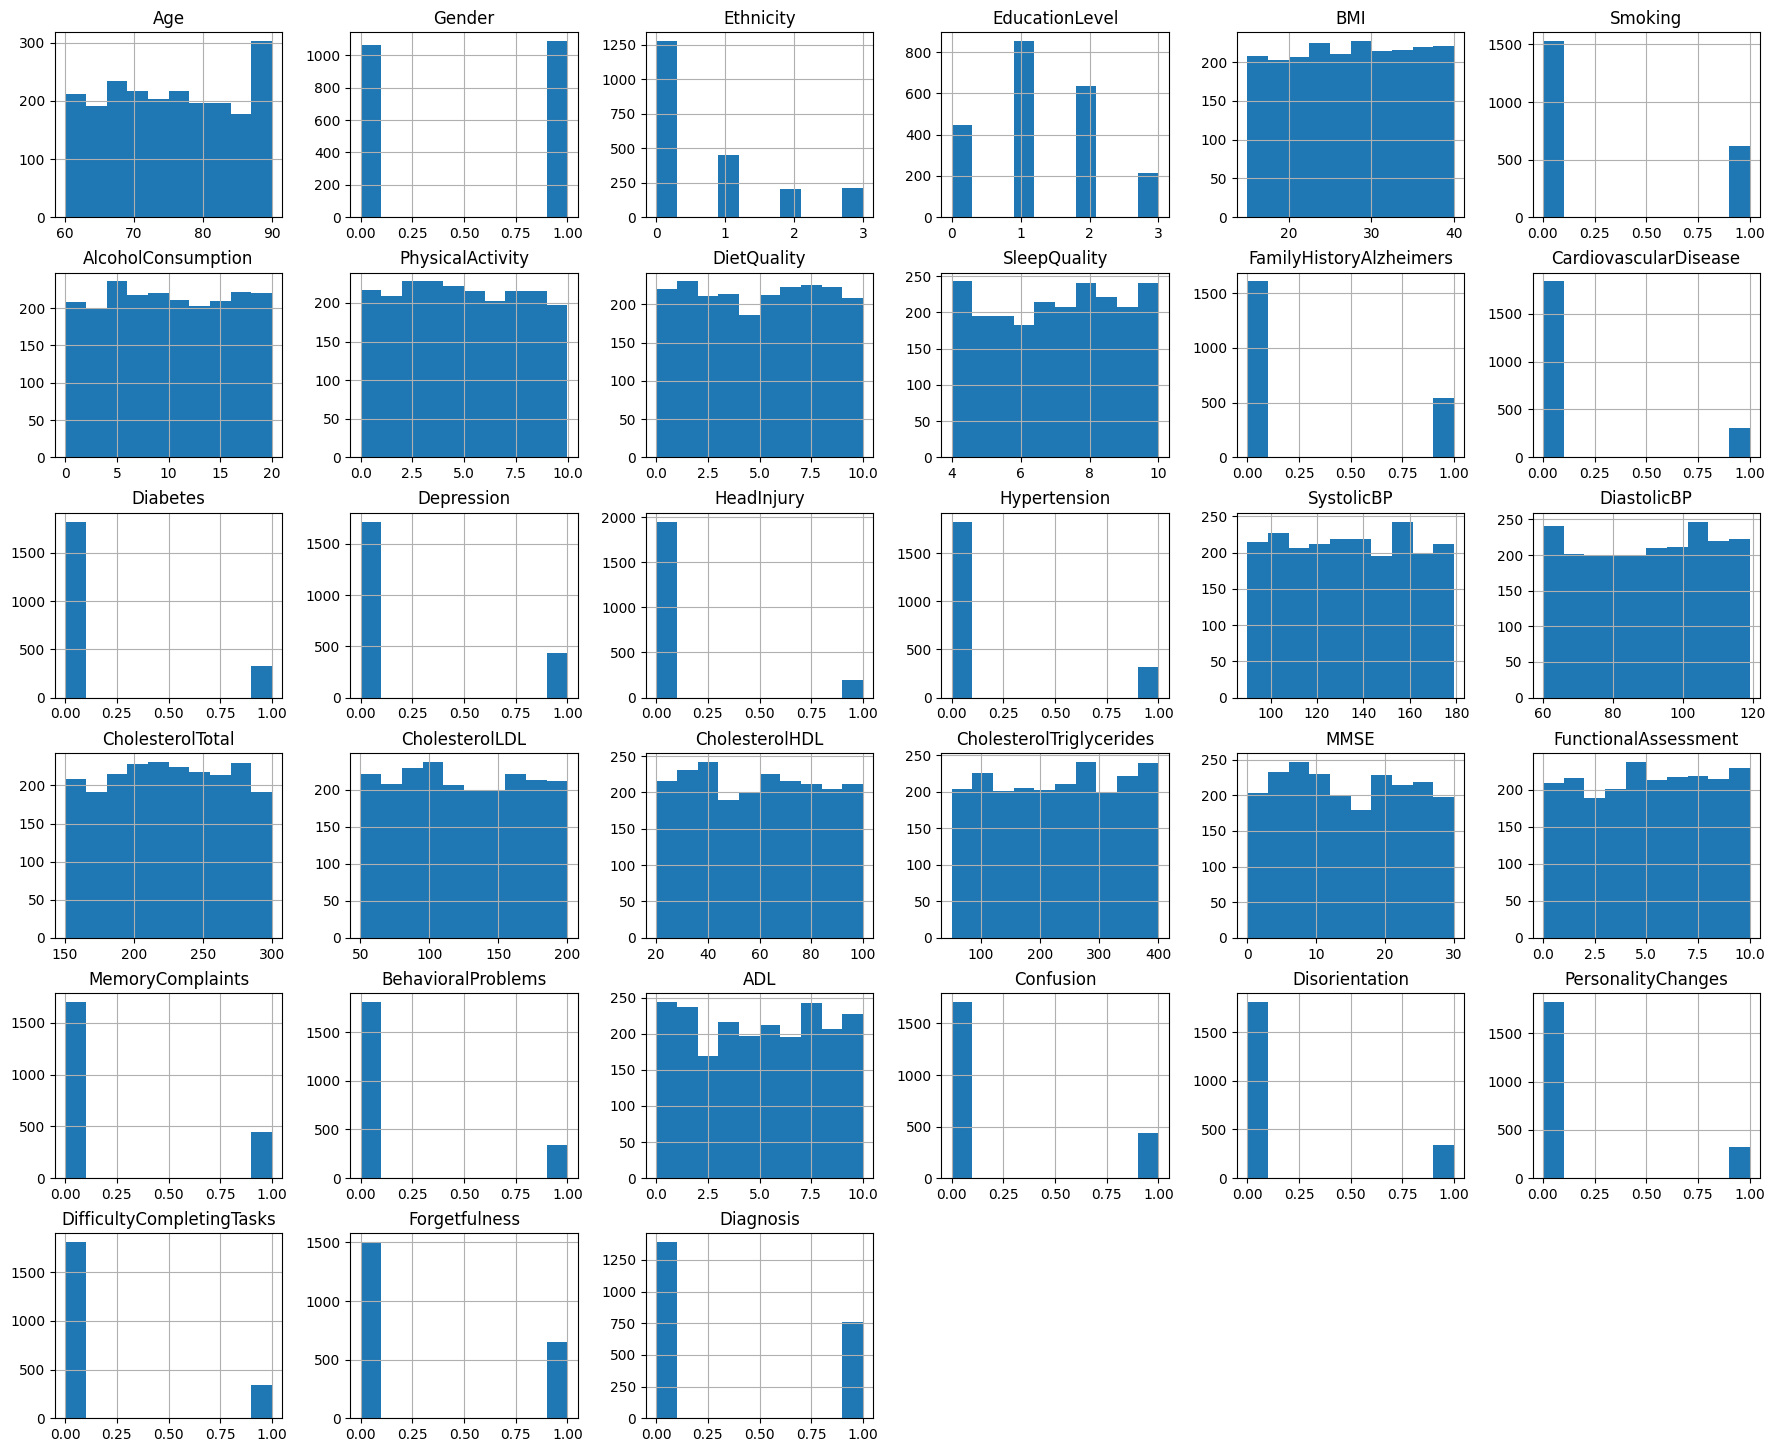

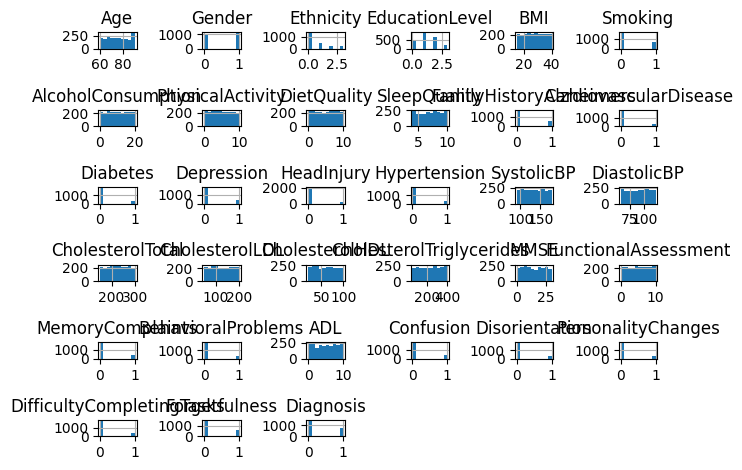

In [47]:
# Удаление пропущенных значений и ненужных столбцов
df.dropna(inplace=True) # Удаление пропущенных значений
df.drop(drop_columns, axis=1, errors='ignore', inplace=True) # Удаление столбцов

# Визуализация признаков и целевой переменной
df.hist(figsize=(22,18))
df.hist()
plt.tight_layout()
plt.show()


Age
--------------------------------------------------
Ассиметрия: 0.046
Эксцесс: -1.189
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.076
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

Gender
--------------------------------------------------
Ассиметрия: -0.025
Эксцесс: -1.999
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.345
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

Ethnicity
--------------------------------------------------
Ассиметрия: 1.229
Эксцесс: 0.231
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.353
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

EducationLevel
--------------------------------------------------
Ассиметрия: 0.209
Эксцесс: -0.754
Колмогорова-Смирнова p-value: 0.000
Колмогорова-Смирнова статистика: 0.229
Колмогорова-Смирнова нормальность: Нет
Уровень значимости: 0.05

BMI
--------------------------------------------------
Ассиметри

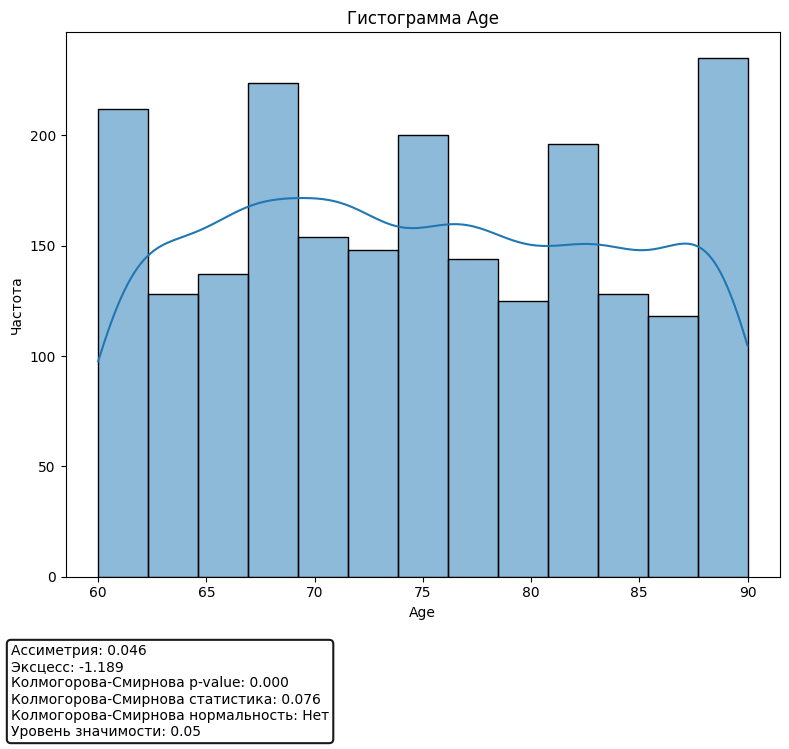

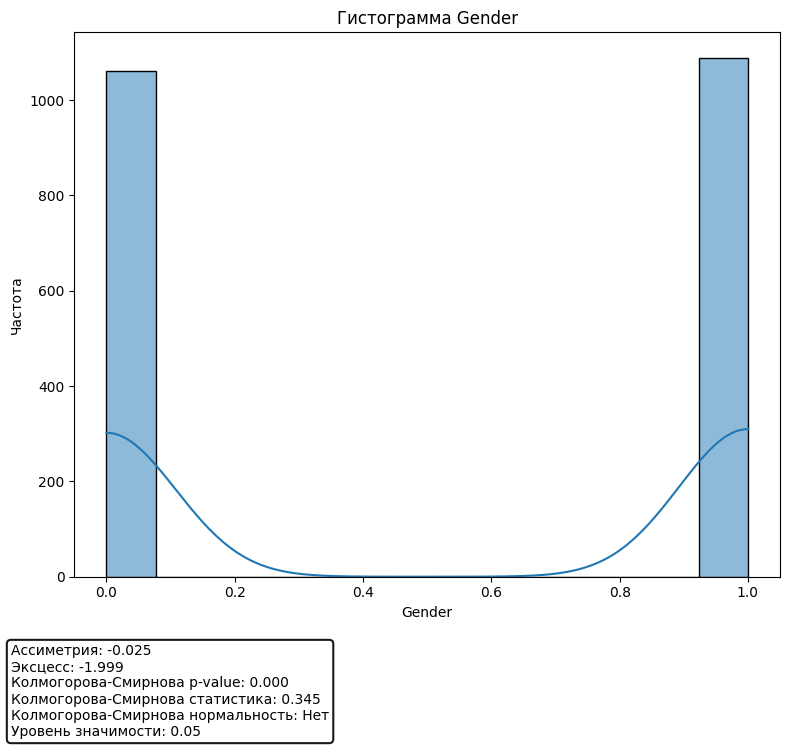

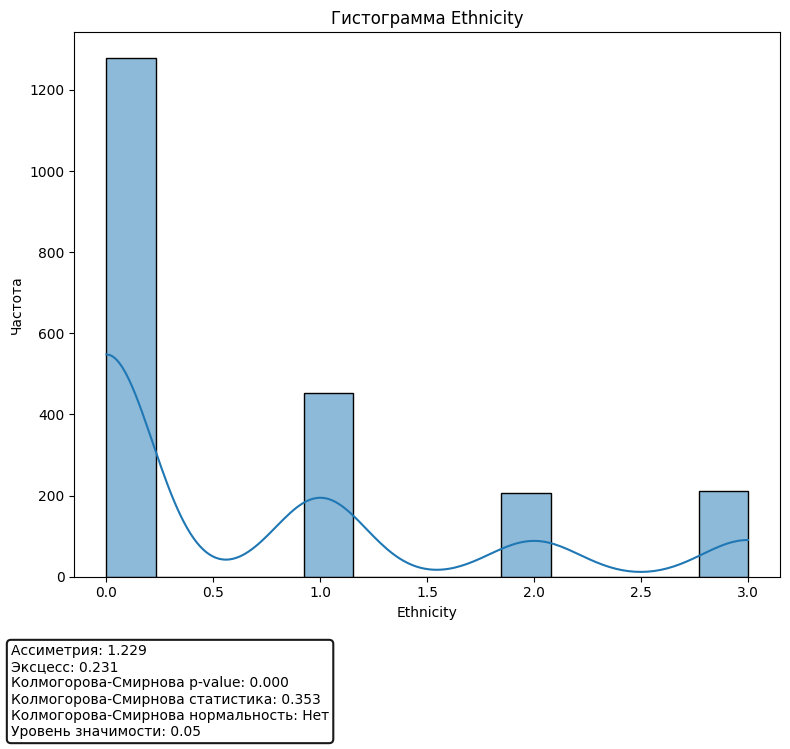

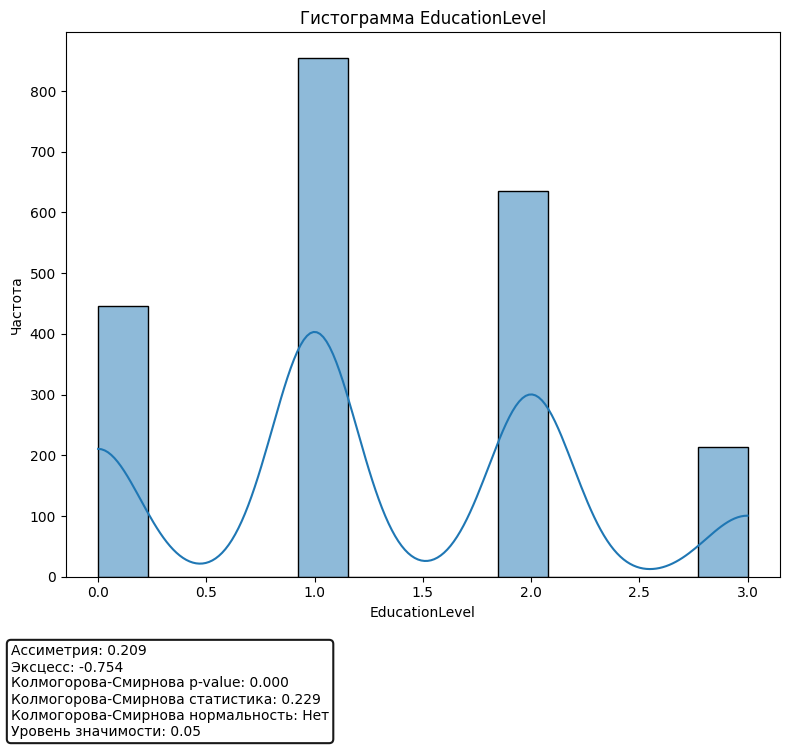

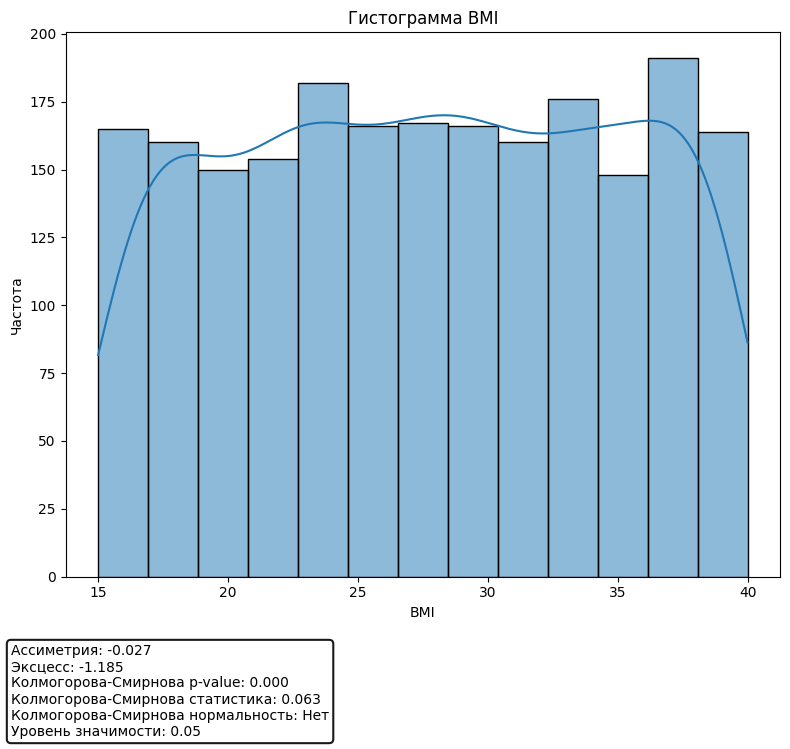

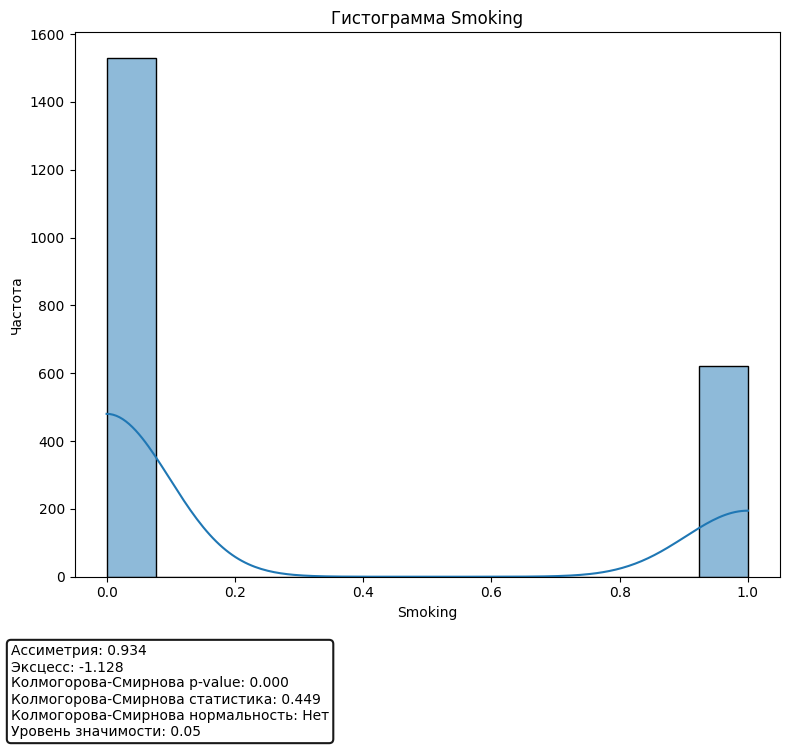

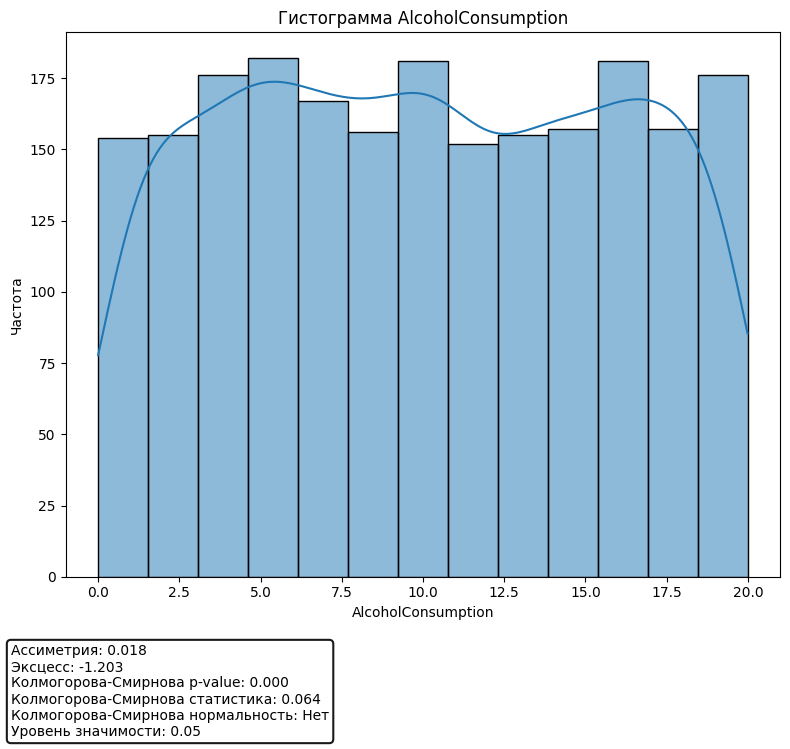

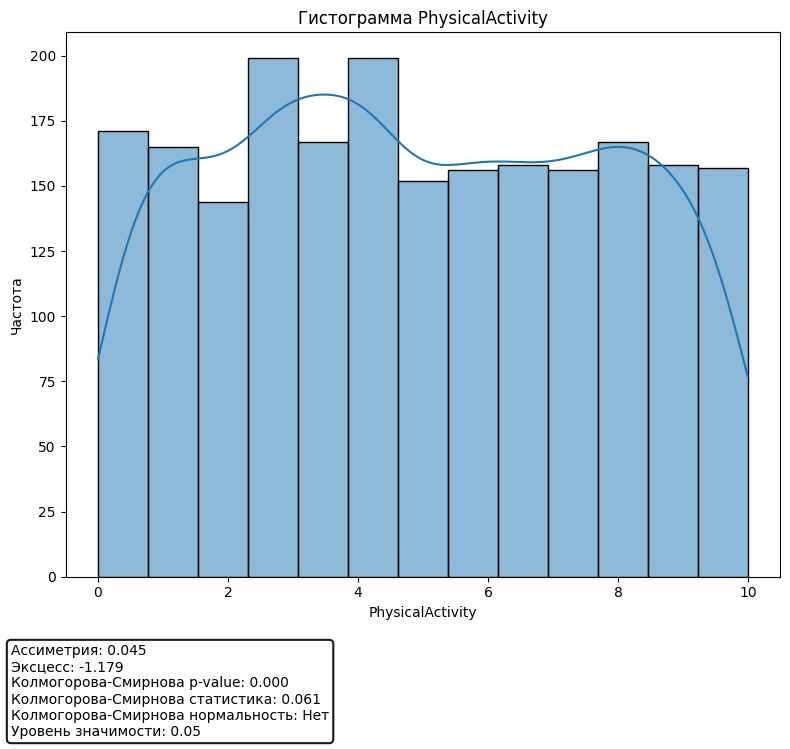

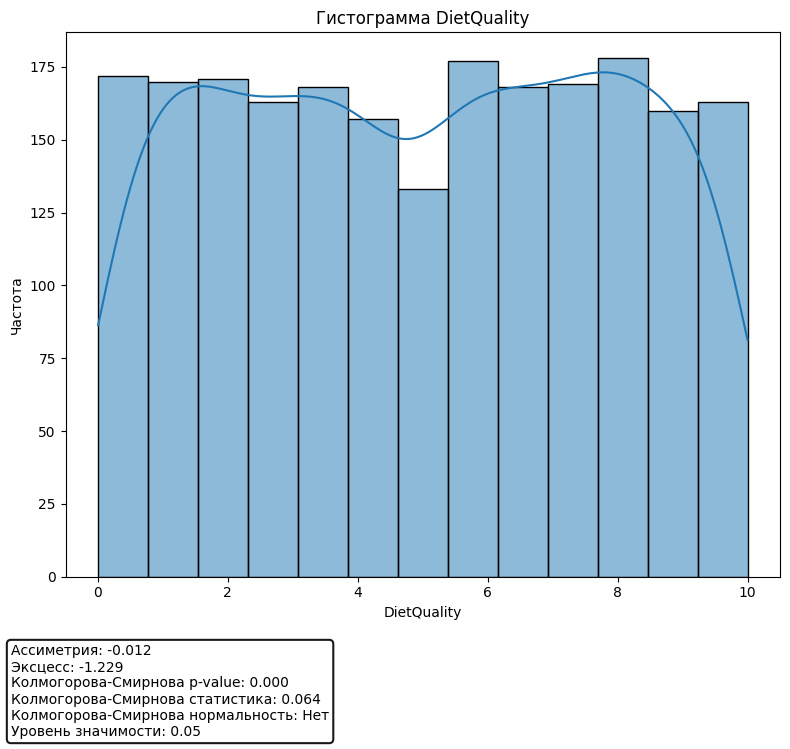

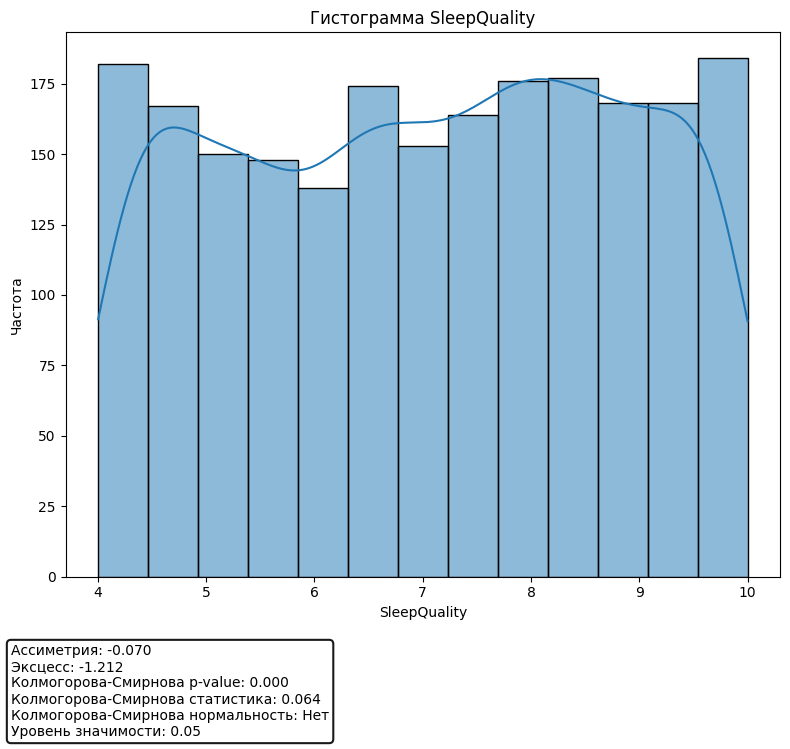

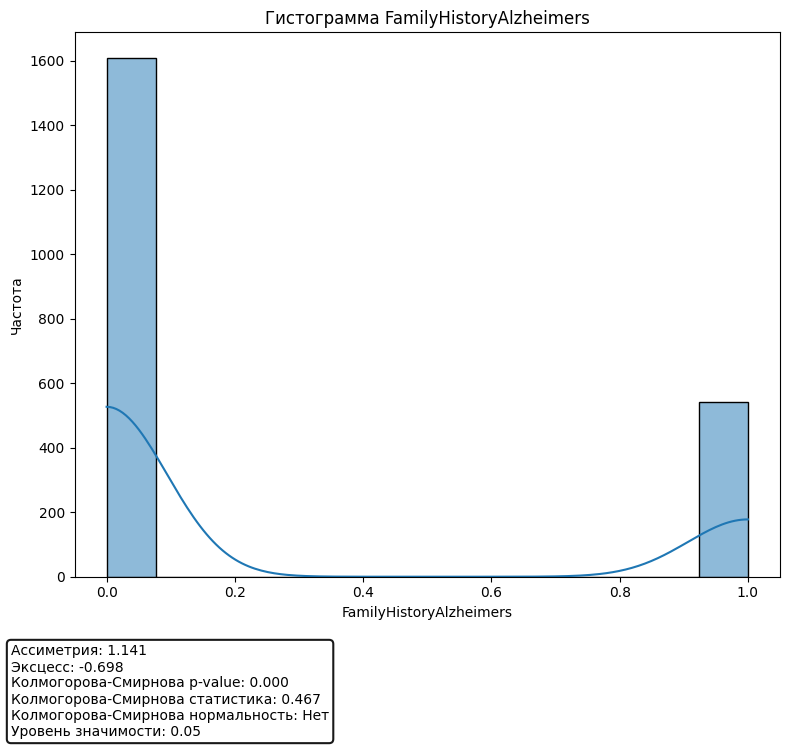

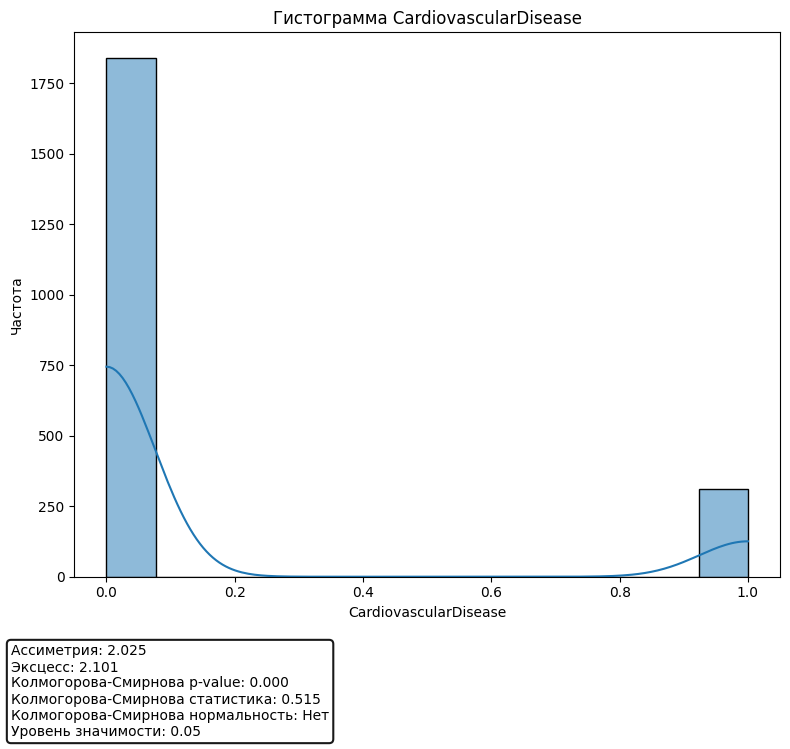

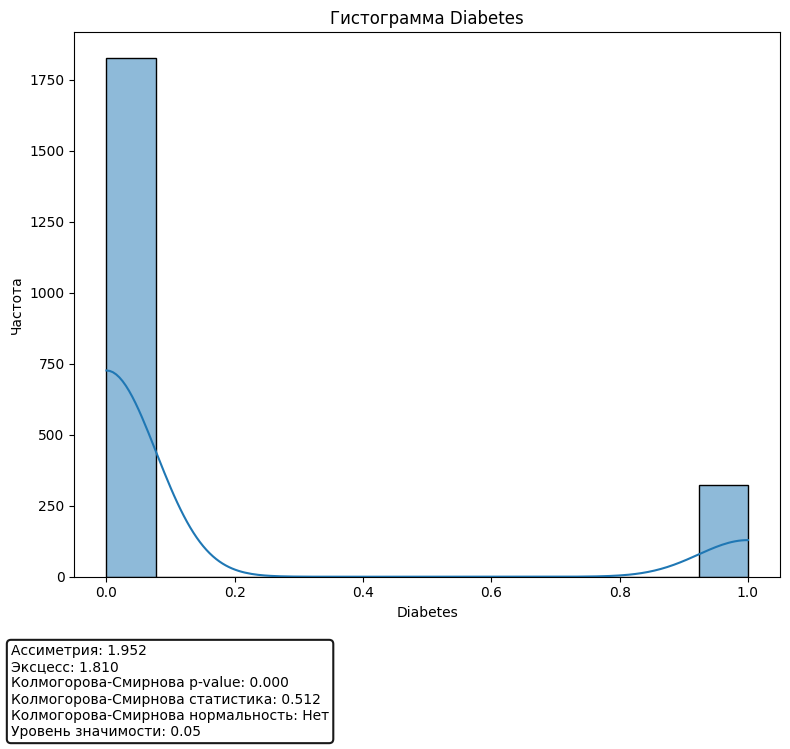

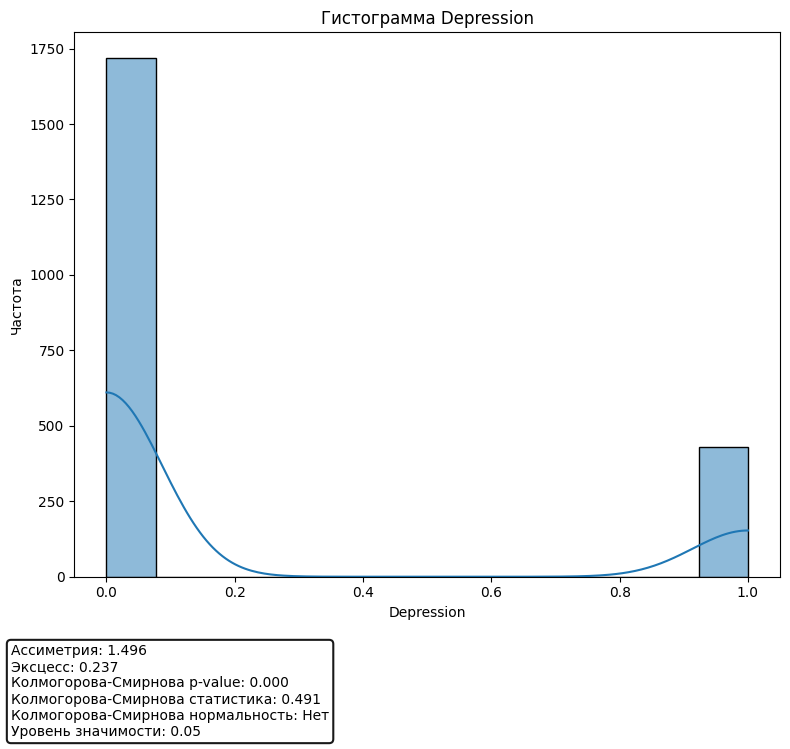

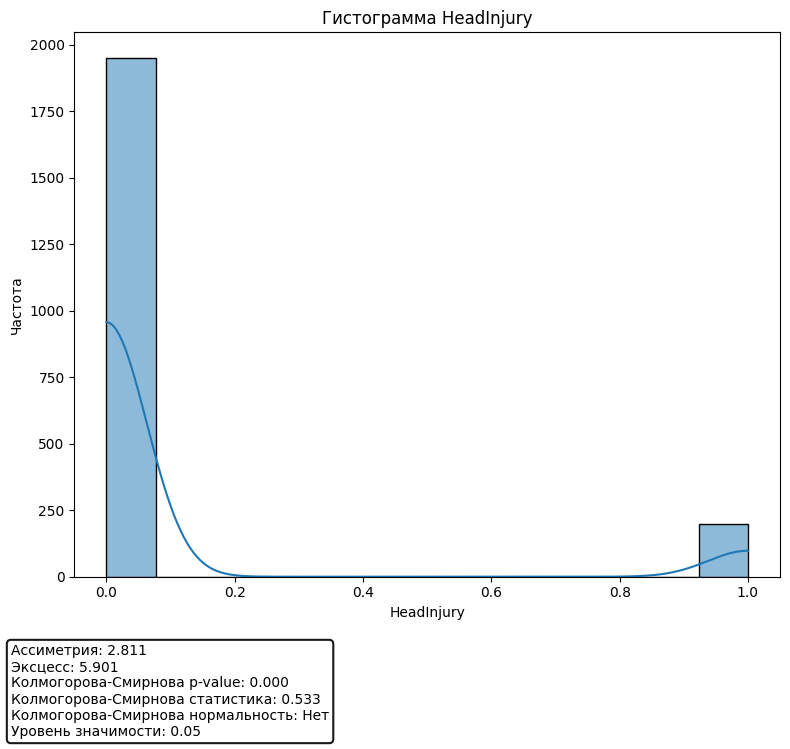

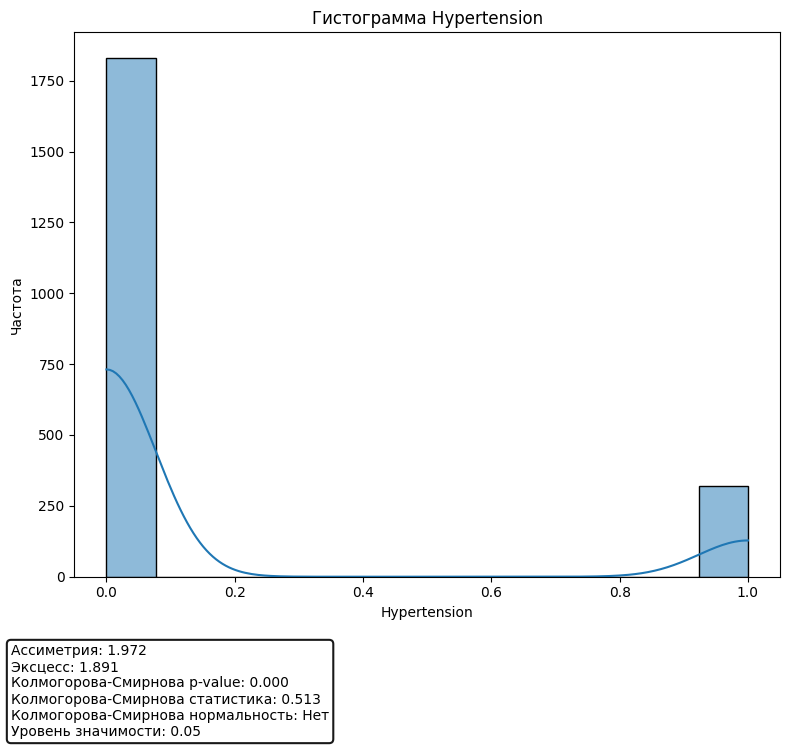

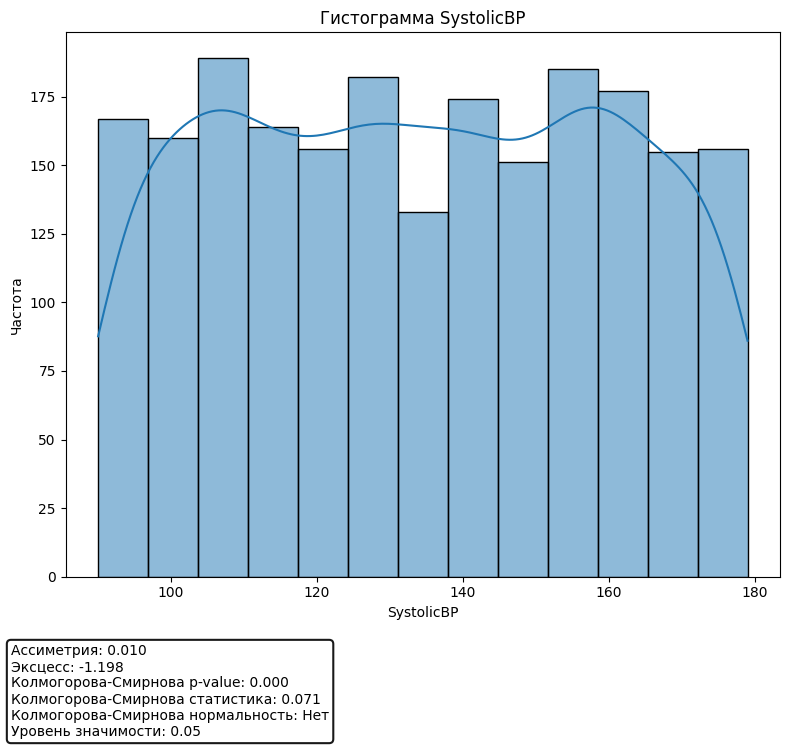

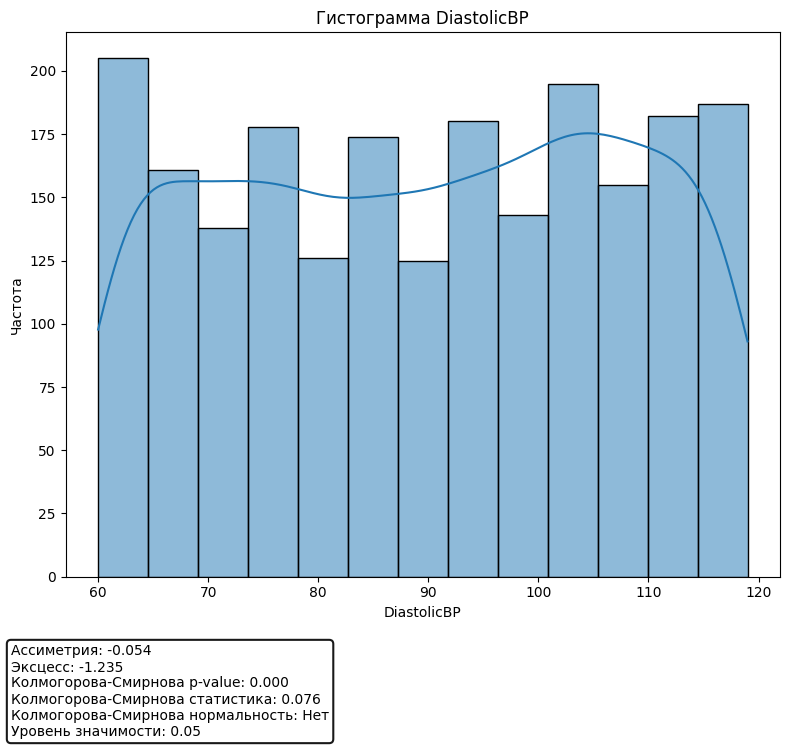

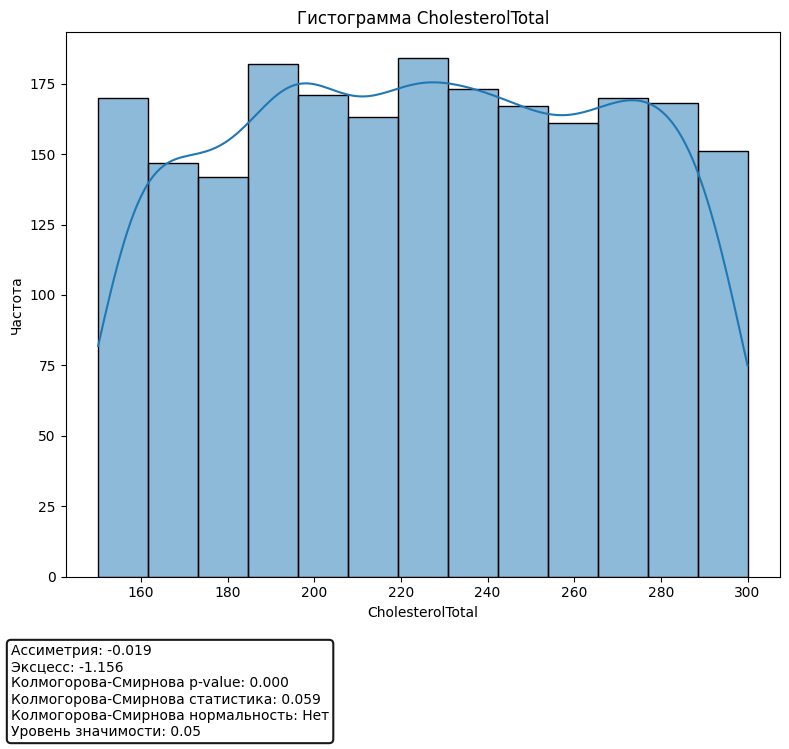

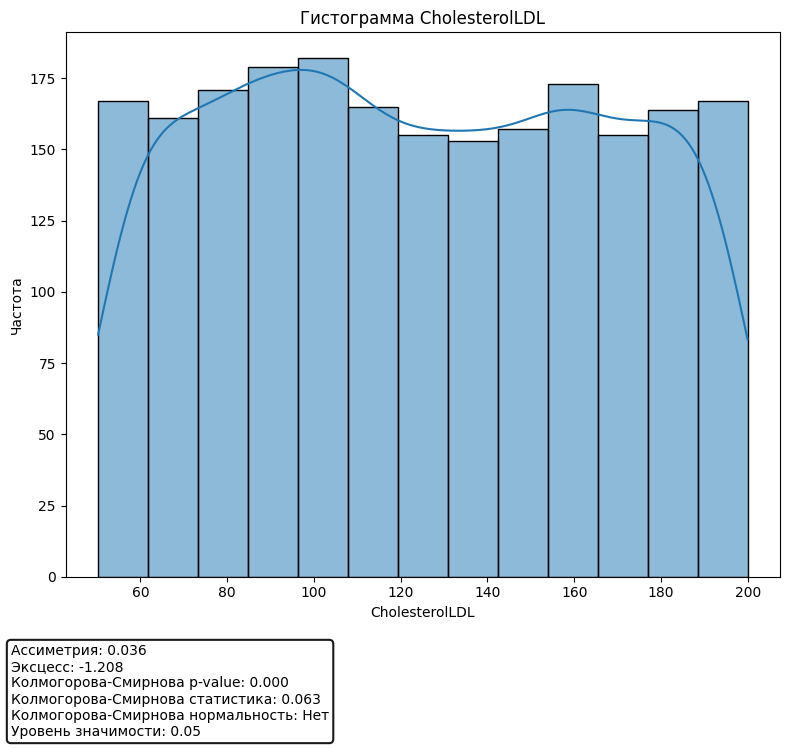

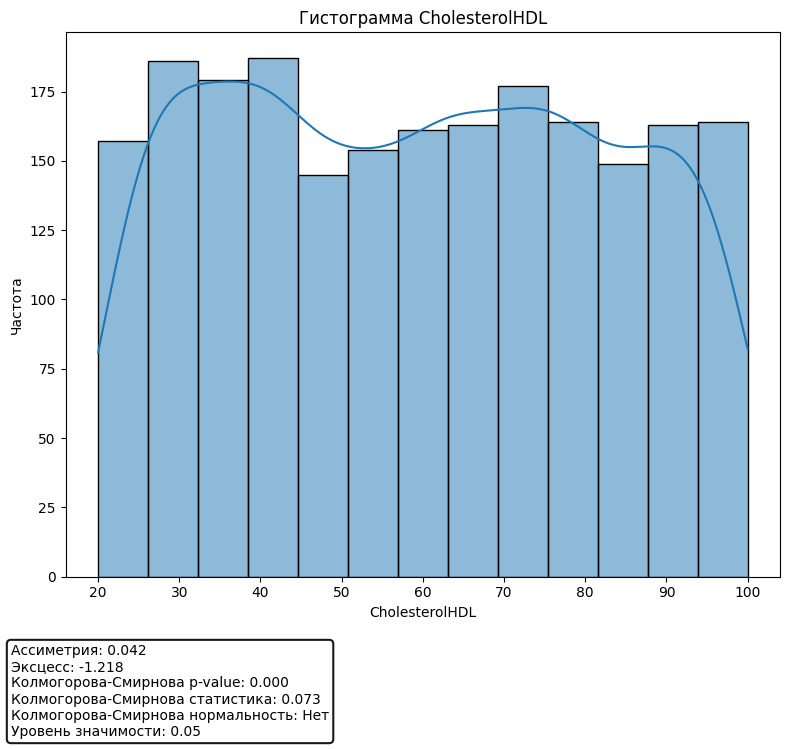

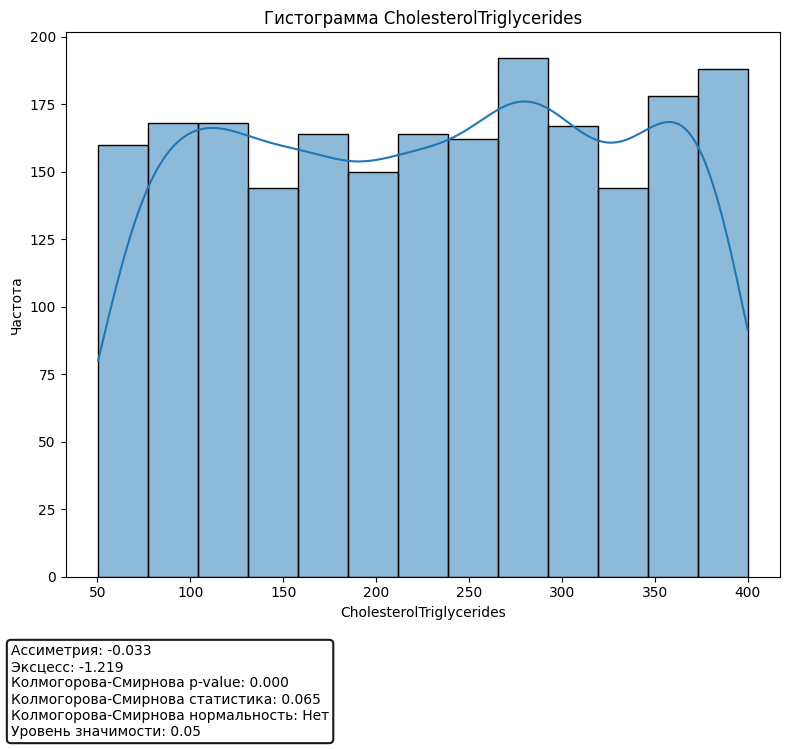

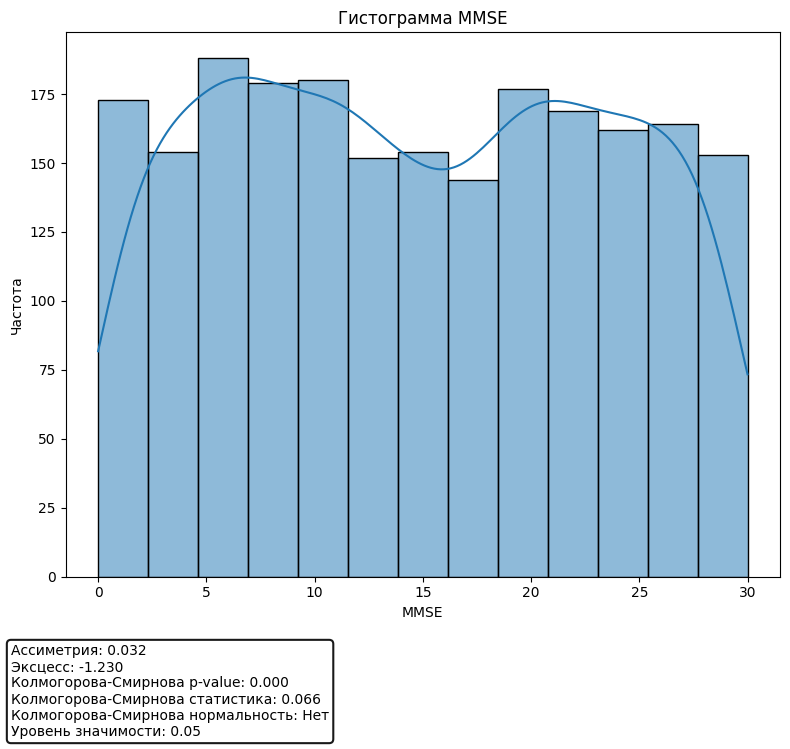

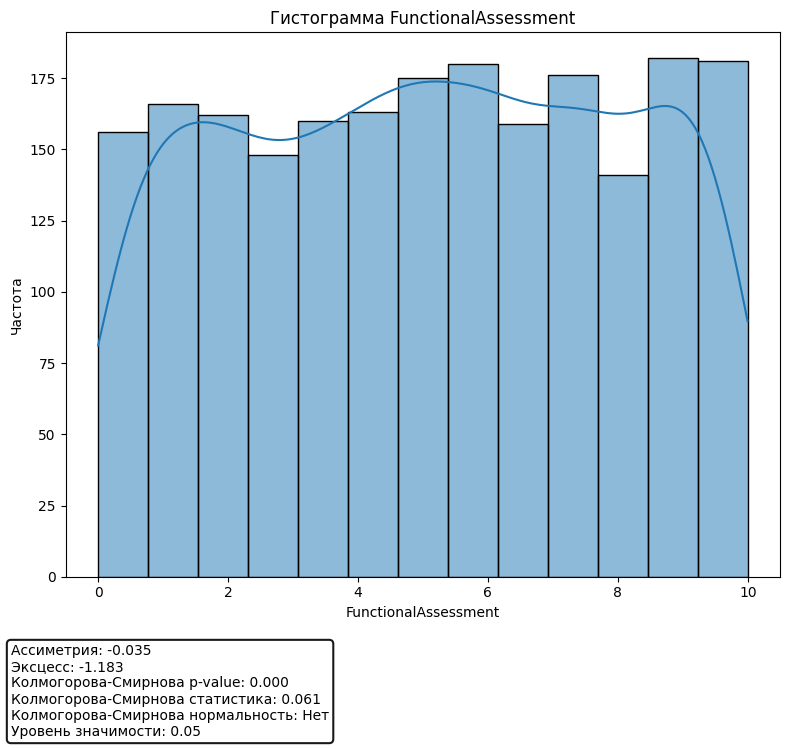

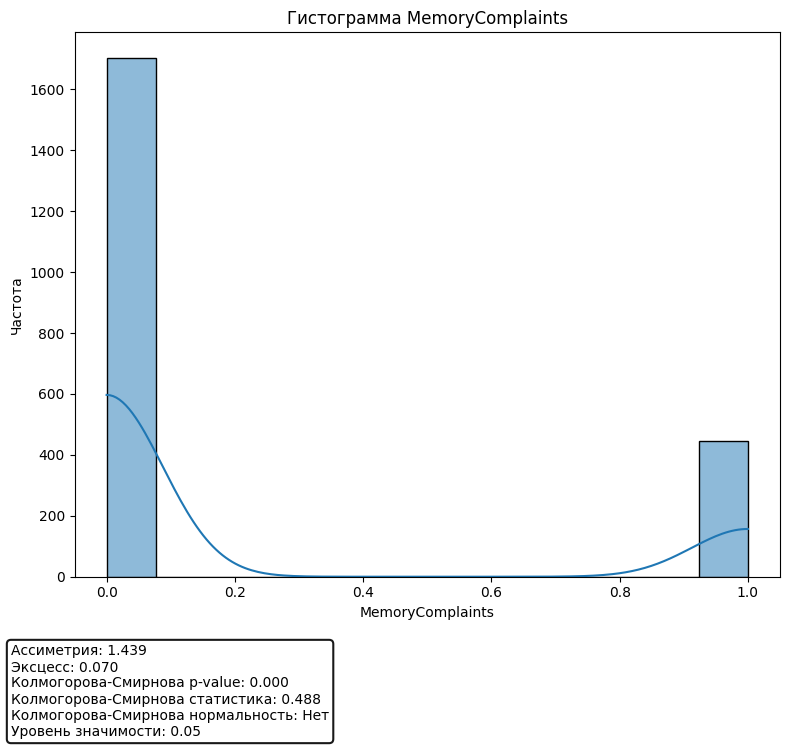

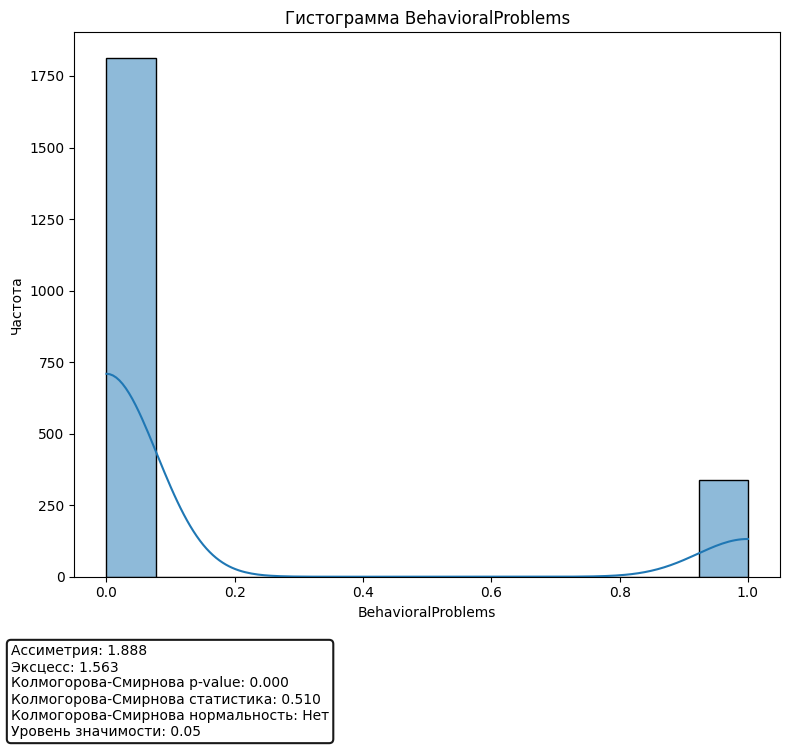

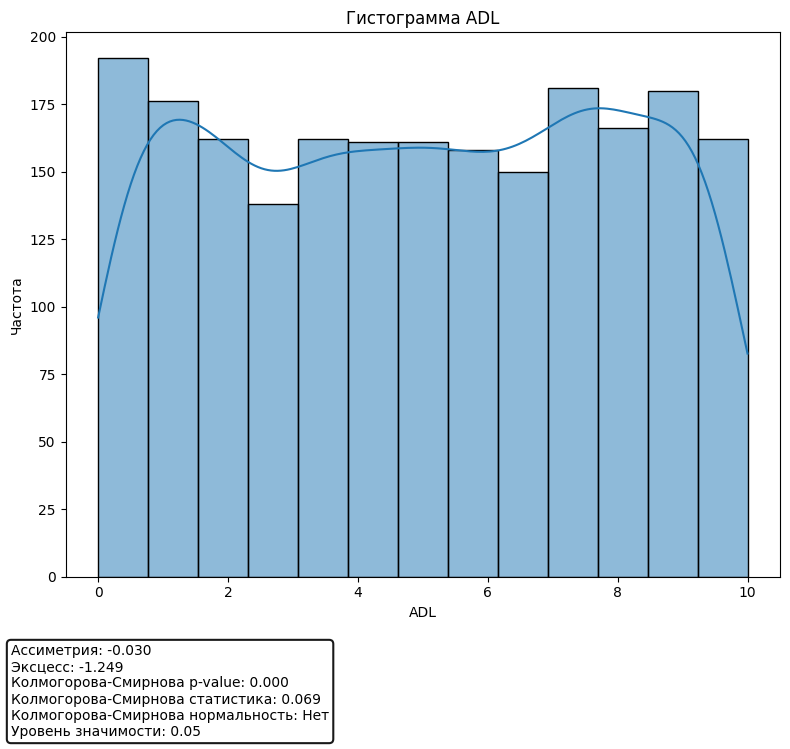

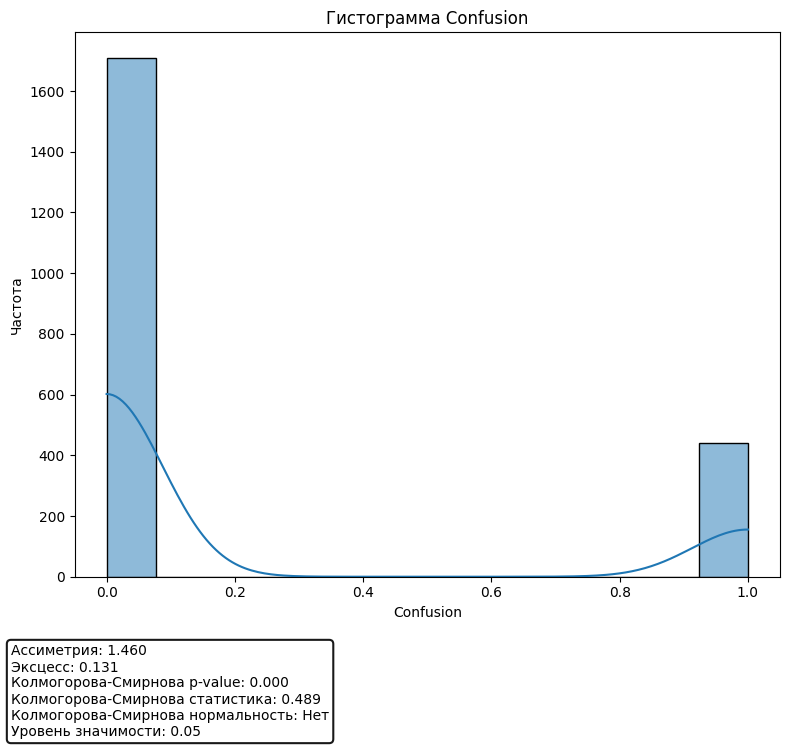

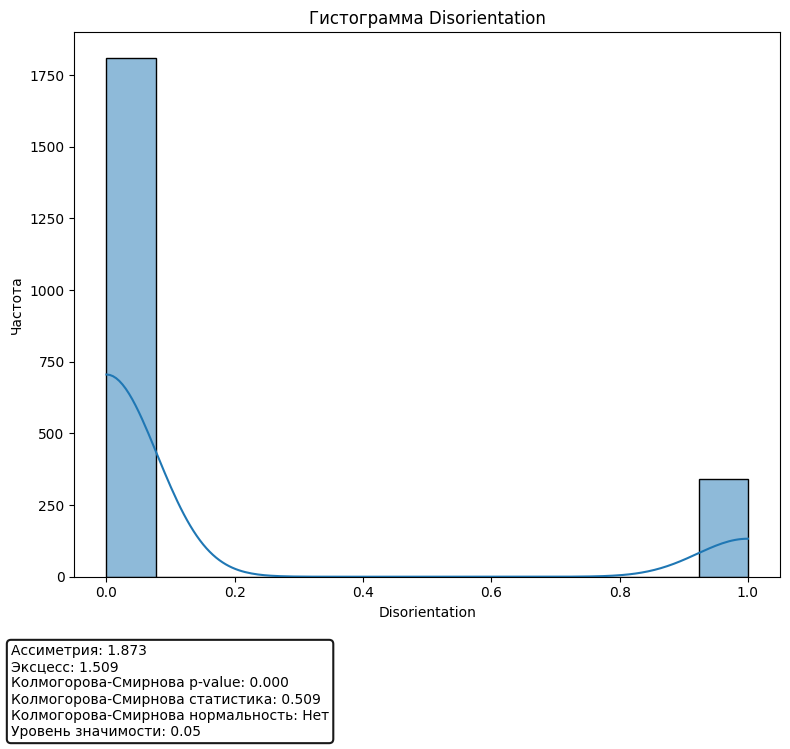

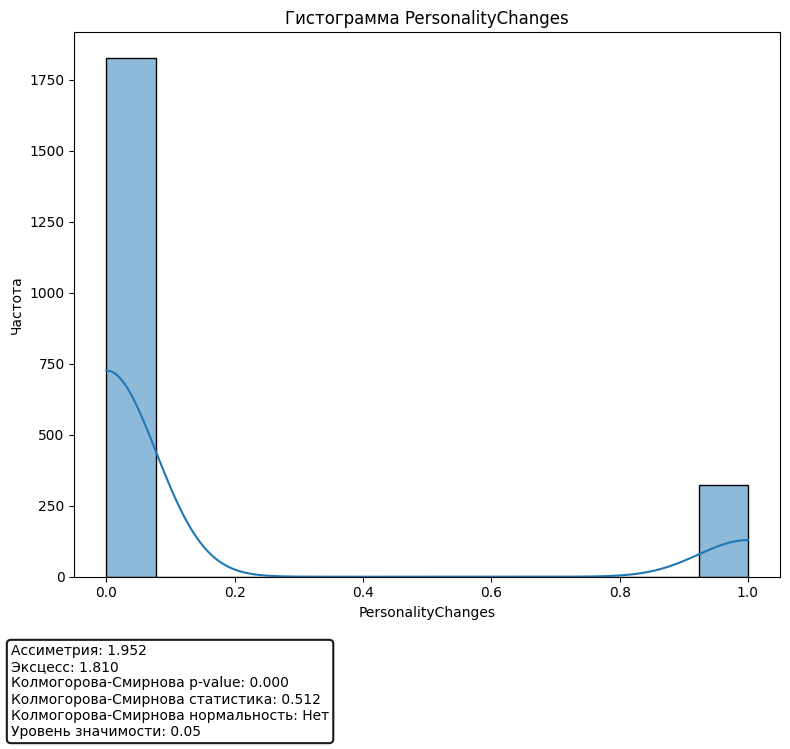

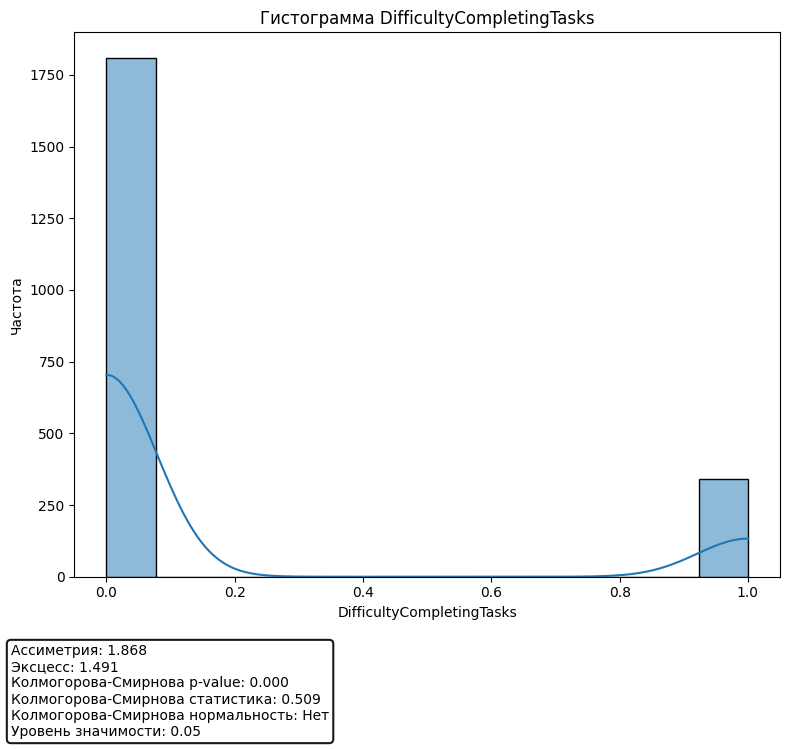

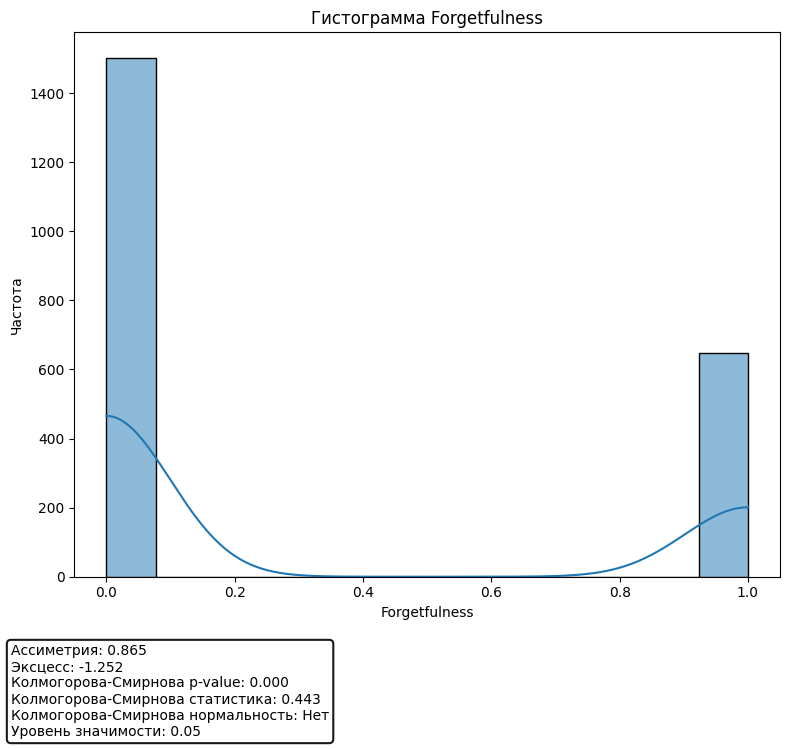

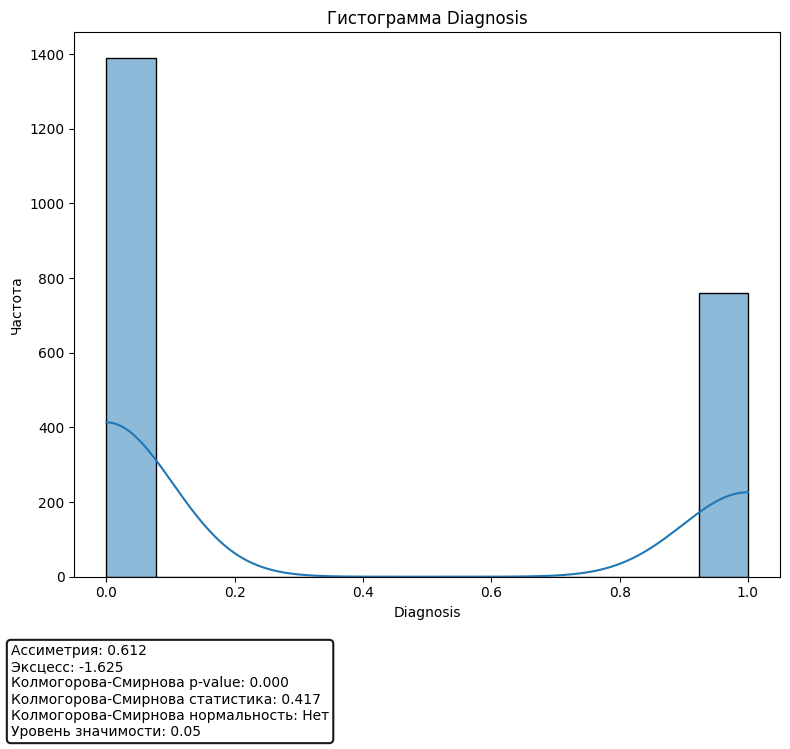

In [48]:
# Проверка распределений на нормальность
ALPHA = 0.05
for _, column in enumerate(df.columns):
    plt.figure(figsize=(8, 8))
    sns.histplot(df[column], kde=True, bins='sturges')

    ks_stat, ks_p_value = kstest(df[column], 'norm', args=(np.mean(df[column]), np.std(df[column])))

    legend = (
        f'Ассиметрия: {skew(df[column]):.3f}\n'
        f'Эксцесс: {kurtosis(df[column]):.3f}\n'
        f'Колмогорова-Смирнова p-value: {(ks_p_value):.3f}\n'
        f'Колмогорова-Смирнова статистика: {(ks_stat):.3f}\n'
        f'Колмогорова-Смирнова нормальность: {'Да' if ks_p_value >= ALPHA else 'Нет'}\n'
        f'Уровень значимости: {ALPHA}'
    )

    plt.figtext(
        0.02, 
        0.02, 
        legend, 
        ha='left', 
        va='bottom', 
        fontsize=10, 
        bbox=dict(
            boxstyle='round', 
            facecolor='white', 
            edgecolor='black',
            linewidth=1.5,
            alpha=0.9
        )
    )

    print(column)
    print(50 * '-')
    print(legend)
    print(50 * '=')
    print()

    plt.title(f'Гистограмма {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.tight_layout(rect=[0, 0.15, 1, 0.95])

In [49]:
df['Diagnosis'].value_counts()

Diagnosis
0    1389
1     760
Name: count, dtype: int64

Ни один из признаков не имеет нормального распределения.

У классов целевой переменной присутствует дисбаланс:
- Класс 0 (Пациент здоров): 1389 пациентов (64.6%)
- Класс 1 (У пациента Альцгеймер): 760 пациентов (35.4%)


## 3. Предобработка данных

In [63]:
from sklearn.model_selection import train_test_split
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']


# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. построение классификационных моделей
### Наивный Байесовский классификатор - BernoulliNB

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Отбор наиболее значимых признаков
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print('Наиболее значимые признаки:')
print(*list(selected_features), sep='\n')

Наиболее значимые признаки:
SleepQuality
CardiovascularDisease
SystolicBP
CholesterolHDL
CholesterolTriglycerides
MMSE
FunctionalAssessment
MemoryComplaints
BehavioralProblems
ADL


In [52]:
from sklearn.naive_bayes import BernoulliNB
# Обучение модели с параметрами по умолчанию
bnb_default = BernoulliNB()
bnb_default.fit(X_train_scaled, y_train)

# Предсказания для обучающего и тестового множеств
y_pred_train_default = bnb_default.predict(X_train_scaled)
y_prob_train_default = bnb_default.predict_proba(X_train_scaled)[:, 1]

y_pred_test_default = bnb_default.predict(X_test_scaled)
y_prob_test_default = bnb_default.predict_proba(X_test_scaled)[:, 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Метрики для обучающего множества
accuracy_train_default = accuracy_score(y_train, y_pred_train_default)
precision_macro_train_default = precision_score(y_train, y_pred_train_default, average='macro')
precision_micro_train_default = precision_score(y_train, y_pred_train_default, average='micro')
recall_macro_train_default = recall_score(y_train, y_pred_train_default, average='macro')
recall_micro_train_default = recall_score(y_train, y_pred_train_default, average='micro')
f1_macro_train_default = f1_score(y_train, y_pred_train_default, average='macro')
f1_micro_train_default = f1_score(y_train, y_pred_train_default, average='micro')
roc_auc_train_default = roc_auc_score(y_train, y_prob_train_default)

print('Метрики для обучающего множества:')
print(f'Accuracy:           {accuracy_train_default:.4f}')
print(f'Precision (macro):  {precision_macro_train_default:.4f}')
print(f'Precision (micro):  {precision_micro_train_default:.4f}')
print(f'Recall (macro):     {recall_macro_train_default:.4f}')
print(f'Recall (micro):     {recall_micro_train_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_default:.4f}')
print(f'ROC-AUC:           {roc_auc_train_default:.4f}')

# Метрики для тестового множества
accuracy_test_default = accuracy_score(y_test, y_pred_test_default)
precision_macro_test_default = precision_score(y_test, y_pred_test_default, average='macro')
precision_micro_test_default = precision_score(y_test, y_pred_test_default, average='micro')
recall_macro_test_default = recall_score(y_test, y_pred_test_default, average='macro')
recall_micro_test_default = recall_score(y_test, y_pred_test_default, average='micro')
f1_macro_test_default = f1_score(y_test, y_pred_test_default, average='macro')
f1_micro_test_default = f1_score(y_test, y_pred_test_default, average='micro')
roc_auc_test_default = roc_auc_score(y_test, y_prob_test_default)

print('\nМетрики для тестового множества:')
print(f'Accuracy:           {accuracy_test_default:.4f}')
print(f'Precision (macro):  {precision_macro_test_default:.4f}')
print(f'Precision (micro):  {precision_micro_test_default:.4f}')
print(f'Recall (macro):     {recall_macro_test_default:.4f}')
print(f'Recall (micro):     {recall_micro_test_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_default:.4f}')
print(f'ROC-AUC:           {roc_auc_test_default:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_bnb))

Метрики для обучающего множества:
Accuracy:           0.8645
Precision (macro):  0.8600
Precision (micro):  0.8645
Recall (macro):     0.8389
Recall (micro):     0.8645
F1-Score (macro):   0.8476
F1-Score (micro):   0.8645
ROC-AUC:           0.9188

Метрики для тестового множества:
Accuracy:           0.8279
Precision (macro):  0.8151
Precision (micro):  0.8279
Recall (macro):     0.8028
Recall (micro):     0.8279
F1-Score (macro):   0.8081
F1-Score (micro):   0.8279
ROC-AUC:           0.8958

Classification Report (Тест):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       278
           1       0.78      0.72      0.75       152

    accuracy                           0.83       430
   macro avg       0.82      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430



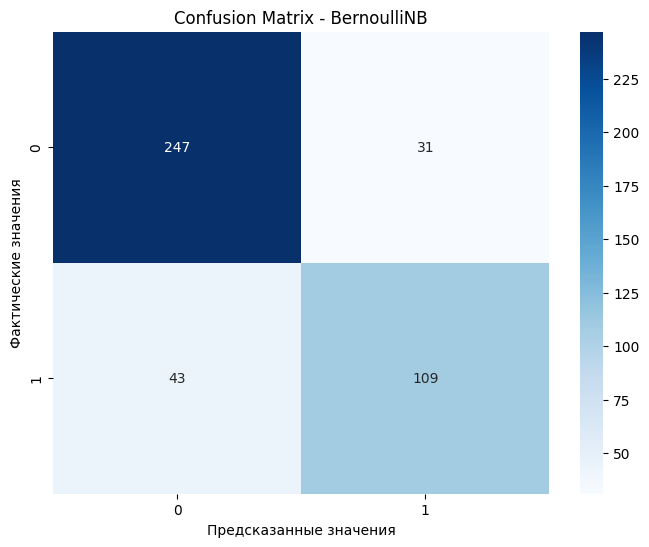

In [54]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8, 6))
cm_bnb = confusion_matrix(y_test, y_pred_test_default)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - BernoulliNB')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

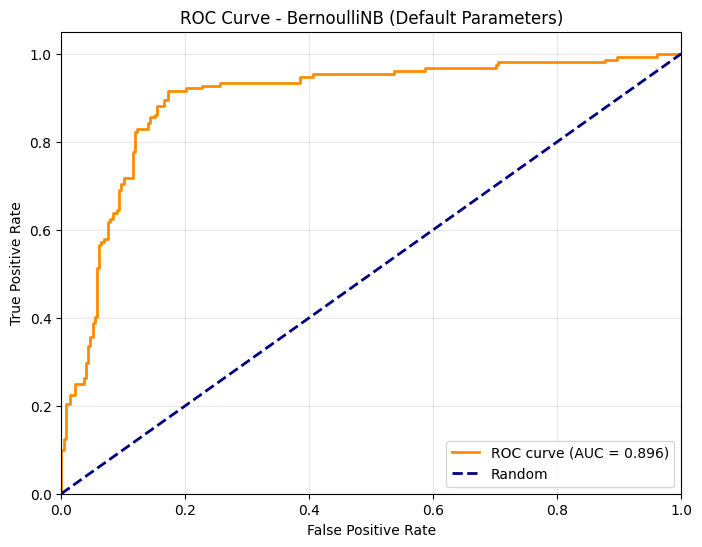

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))
fpr_default, tpr_default, _ = roc_curve(y_test, y_prob_test_default)
plt.plot(fpr_default, tpr_default, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_default:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BernoulliNB (Default Parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

#### Обучение модели с подобранными эффективными гиперпараметрами

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV
# Подбор гиперпараметров
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
    'binarize': [0.0, 0.1, 0.5, 1.0],
    'fit_prior': [True, False]
}

bnb_grid = GridSearchCV(
    BernoulliNB(), 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

bnb_grid.fit(X_train_selected, y_train)

print(f'Лучшие параметры: {bnb_grid.best_params_}')
print(f'Лучшая точность на CV: {bnb_grid.best_score_:.4f}')

Лучшие параметры: {'alpha': 5.0, 'binarize': 0.0, 'fit_prior': False}
Лучшая точность на CV: 0.8668


In [57]:
#Обучение модели с лучшими параметрами
bnb_best = bnb_grid.best_estimator_
bnb_best.fit(X_train_selected, y_train)

y_pred_bnb = bnb_best.predict(X_test_selected)
y_prob_bnb = bnb_best.predict_proba(X_test_selected)[:, 1]

y_pred_train = bnb_best.predict(X_train_selected)
y_prob_train = bnb_best.predict_proba(X_train_selected)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report

print('Метрики для обучающего множества:')

accuracy_train = accuracy_score(y_train, y_pred_train)
precision_macro_train = precision_score(y_train, y_pred_train, average='macro')
precision_micro_train = precision_score(y_train, y_pred_train, average='micro')
recall_macro_train = recall_score(y_train, y_pred_train, average='macro')
recall_micro_train = recall_score(y_train, y_pred_train, average='micro')
f1_macro_train = f1_score(y_train, y_pred_train, average='macro')
f1_micro_train = f1_score(y_train, y_pred_train, average='micro')
roc_auc_train = roc_auc_score(y_train, y_prob_train)


print(f'Accuracy:           {accuracy_train:.4f}')
print(f'Precision (macro):  {precision_macro_train:.4f}')
print(f'Precision (micro):  {precision_micro_train:.4f}')
print(f'Recall (macro):     {recall_macro_train:.4f}')
print(f'Recall (micro):     {recall_micro_train:.4f}')
print(f'F1-Score (macro):   {f1_macro_train:.4f}')
print(f'F1-Score (micro):   {f1_micro_train:.4f}')
print(f'ROC-AUC:           {roc_auc_train:.4f}')

print('\nМетрики для тестового множества:')

accuracy_test = accuracy_score(y_test, y_pred_bnb)
precision_macro_test = precision_score(y_test, y_pred_bnb, average='macro')
precision_micro_test = precision_score(y_test, y_pred_bnb, average='micro')
recall_macro_test = recall_score(y_test, y_pred_bnb, average='macro')
recall_micro_test = recall_score(y_test, y_pred_bnb, average='micro')
f1_macro_test = f1_score(y_test, y_pred_bnb, average='macro')
f1_micro_test = f1_score(y_test, y_pred_bnb, average='micro')
roc_auc_test = roc_auc_score(y_test, y_prob_bnb)

print(f'Accuracy:           {accuracy_test:.4f}')
print(f'Precision (macro):  {precision_macro_test:.4f}')
print(f'Precision (micro):  {precision_micro_test:.4f}')
print(f'Recall (macro):     {recall_macro_test:.4f}')
print(f'Recall (micro):     {recall_micro_test:.4f}')
print(f'F1-Score (macro):   {f1_macro_test:.4f}')
print(f'F1-Score (micro):   {f1_micro_test:.4f}')
print(f'ROC-AUC:           {roc_auc_test:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_bnb))


Метрики для обучающего множества:
Accuracy:           0.8720
Precision (macro):  0.8574
Precision (micro):  0.8720
Recall (macro):     0.8794
Recall (micro):     0.8720
F1-Score (macro):   0.8647
F1-Score (micro):   0.8720
ROC-AUC:           0.9194

Метрики для тестового множества:
Accuracy:           0.8721
Precision (macro):  0.8586
Precision (micro):  0.8721
Recall (macro):     0.8847
Recall (micro):     0.8721
F1-Score (macro):   0.8658
F1-Score (micro):   0.8721
ROC-AUC:           0.9009
              precision    recall  f1-score   support

           0       0.96      0.84      0.89       278
           1       0.76      0.93      0.84       152

    accuracy                           0.87       430
   macro avg       0.86      0.88      0.87       430
weighted avg       0.89      0.87      0.87       430



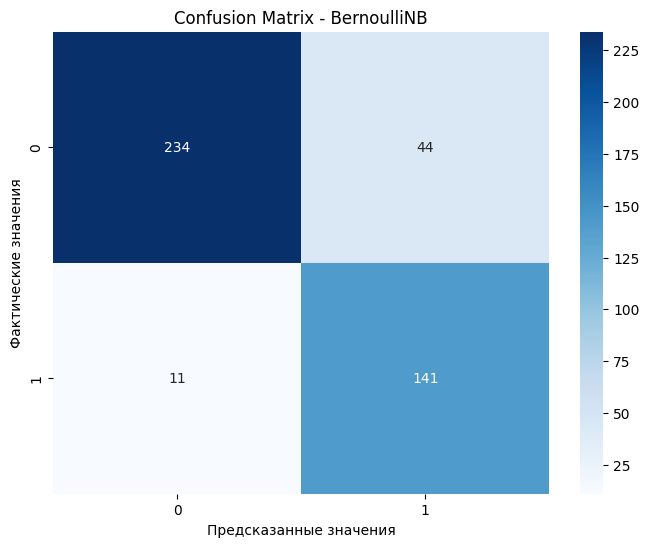

In [59]:
plt.figure(figsize=(8, 6))
cm_bnb = confusion_matrix(y_test, y_pred_bnb)
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - BernoulliNB')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

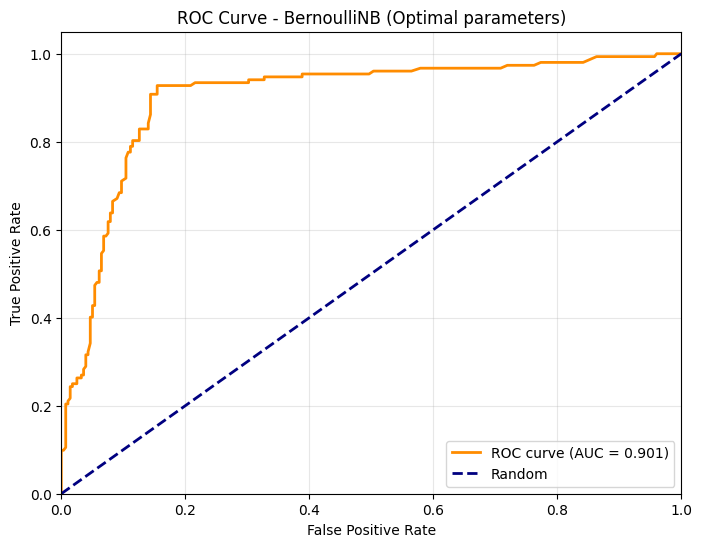

In [ ]:
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob_bnb)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_bnb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - BernoulliNB (Optimal parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Из результатов видно, что качество модели довольно высокое. Показатели на тренировочных и тестовых множествах примерно одинаковые, что говорит о том, что переобучения почти нет. После подбора оптимальных гиперпараметров, качество модели улучшилось, переобучение практически пропало. Особенно ценно изменение показателя Recall (Без подбора параметров - 0.8279, после подбора параметров - 0.8721), что говорит об уменьшении ложноотрицательных результатов. Примерно так же изменился и показатель Precision (Без подбора параметров - 0.8721, после подбора параметров - 0.8279)

### Деревья решений (Decision Tree)

In [67]:
from sklearn.tree import DecisionTreeClassifier

dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_scaled, y_train)

# Предсказания для обучающего и тестового множеств
y_pred_train_dt_default = dt_default.predict(X_train)
y_prob_train_dt_default = dt_default.predict_proba(X_train)[:, 1]

y_pred_test_dt_default = dt_default.predict(X_test)
y_prob_test_dt_default = dt_default.predict_proba(X_test)[:, 1]

In [ ]:
# Метрики для обучающего множества
accuracy_train_dt_default = accuracy_score(y_train, y_pred_train_dt_default)
precision_macro_train_dt_default = precision_score(y_train, y_pred_train_dt_default, average='macro')
precision_micro_train_dt_default = precision_score(y_train, y_pred_train_dt_default, average='micro')
recall_macro_train_dt_default = recall_score(y_train, y_pred_train_dt_default, average='macro')
recall_micro_train_dt_default = recall_score(y_train, y_pred_train_dt_default, average='micro')
f1_macro_train_dt_default = f1_score(y_train, y_pred_train_dt_default, average='macro')
f1_micro_train_dt_default = f1_score(y_train, y_pred_train_dt_default, average='micro')
roc_auc_train_dt_default = roc_auc_score(y_train, y_prob_train_dt_default)

print('ОБУЧАЮЩЕЕ МНОЖЕСТВО:')
print(f'Accuracy:           {accuracy_train_dt_default:.4f}')
print(f'Precision (macro):  {precision_macro_train_dt_default:.4f}')
print(f'Precision (micro):  {precision_micro_train_dt_default:.4f}')
print(f'Recall (macro):     {recall_macro_train_dt_default:.4f}')
print(f'Recall (micro):     {recall_micro_train_dt_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_dt_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_dt_default:.4f}')
print(f'ROC-AUC:           {roc_auc_train_dt_default:.4f}')

# Метрики для тестового множества
accuracy_test_dt_default = accuracy_score(y_test, y_pred_test_dt_default)
precision_macro_test_dt_default = precision_score(y_test, y_pred_test_dt_default, average='macro')
precision_micro_test_dt_default = precision_score(y_test, y_pred_test_dt_default, average='micro')
recall_macro_test_dt_default = recall_score(y_test, y_pred_test_dt_default, average='macro')
recall_micro_test_dt_default = recall_score(y_test, y_pred_test_dt_default, average='micro')
f1_macro_test_dt_default = f1_score(y_test, y_pred_test_dt_default, average='macro')
f1_micro_test_dt_default = f1_score(y_test, y_pred_test_dt_default, average='micro')
roc_auc_test_dt_default = roc_auc_score(y_test, y_prob_test_dt_default)

print('\nТЕСТОВОЕ МНОЖЕСТВО:')
print(f'Accuracy:           {accuracy_test_dt_default:.4f}')
print(f'Precision (macro):  {precision_macro_test_dt_default:.4f}')
print(f'Precision (micro):  {precision_micro_test_dt_default:.4f}')
print(f'Recall (macro):     {recall_macro_test_dt_default:.4f}')
print(f'Recall (micro):     {recall_micro_test_dt_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_dt_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_dt_default:.4f}')
print(f'ROC-AUC:           {roc_auc_test_dt_default:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_test_dt_default))

ОБУЧАЮЩЕЕ МНОЖЕСТВО:
Accuracy:           0.7109
Precision (macro):  0.6922
Precision (micro):  0.7109
Recall (macro):     0.6348
Recall (micro):     0.7109
F1-Score (macro):   0.6392
F1-Score (micro):   0.7109
ROC-AUC:           0.6348

ТЕСТОВОЕ МНОЖЕСТВО:
Accuracy:           0.6744
Precision (macro):  0.6348
Precision (micro):  0.6744
Recall (macro):     0.5976
Recall (micro):     0.6744
F1-Score (macro):   0.5975
F1-Score (micro):   0.6744
ROC-AUC:           0.5976
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       278
           1       0.57      0.34      0.42       152

    accuracy                           0.67       430
   macro avg       0.63      0.60      0.60       430
weighted avg       0.65      0.67      0.65       430



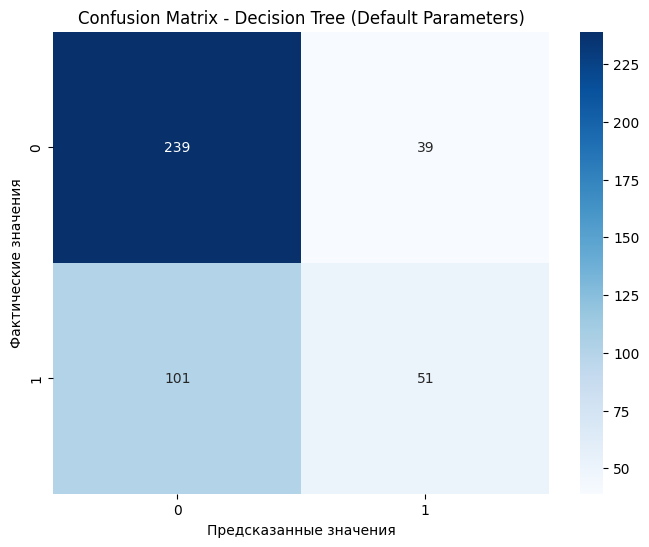

In [69]:
plt.figure(figsize=(8, 6))
cm_dt_default = confusion_matrix(y_test, y_pred_test_dt_default)
sns.heatmap(cm_dt_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - Decision Tree (Default Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

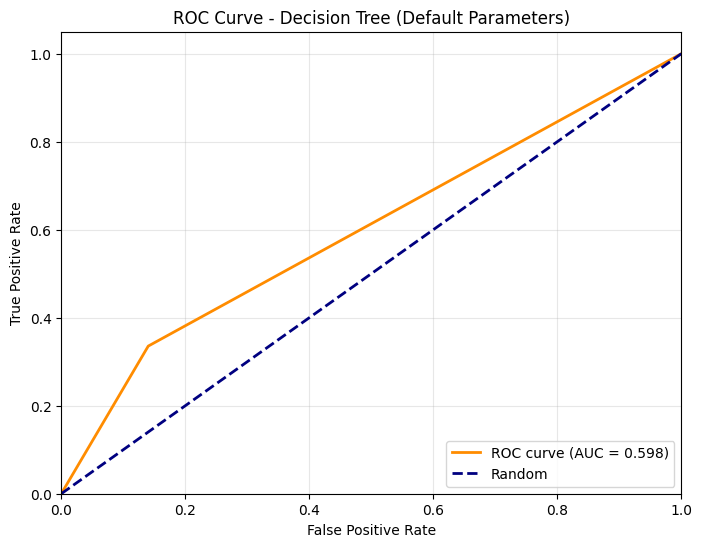

In [ ]:
plt.figure(figsize=(8, 6))
fpr_dt_default, tpr_dt_default, _ = roc_curve(y_test, y_prob_test_dt_default)
plt.plot(fpr_dt_default, tpr_dt_default, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_dt_default:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree (Default Parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

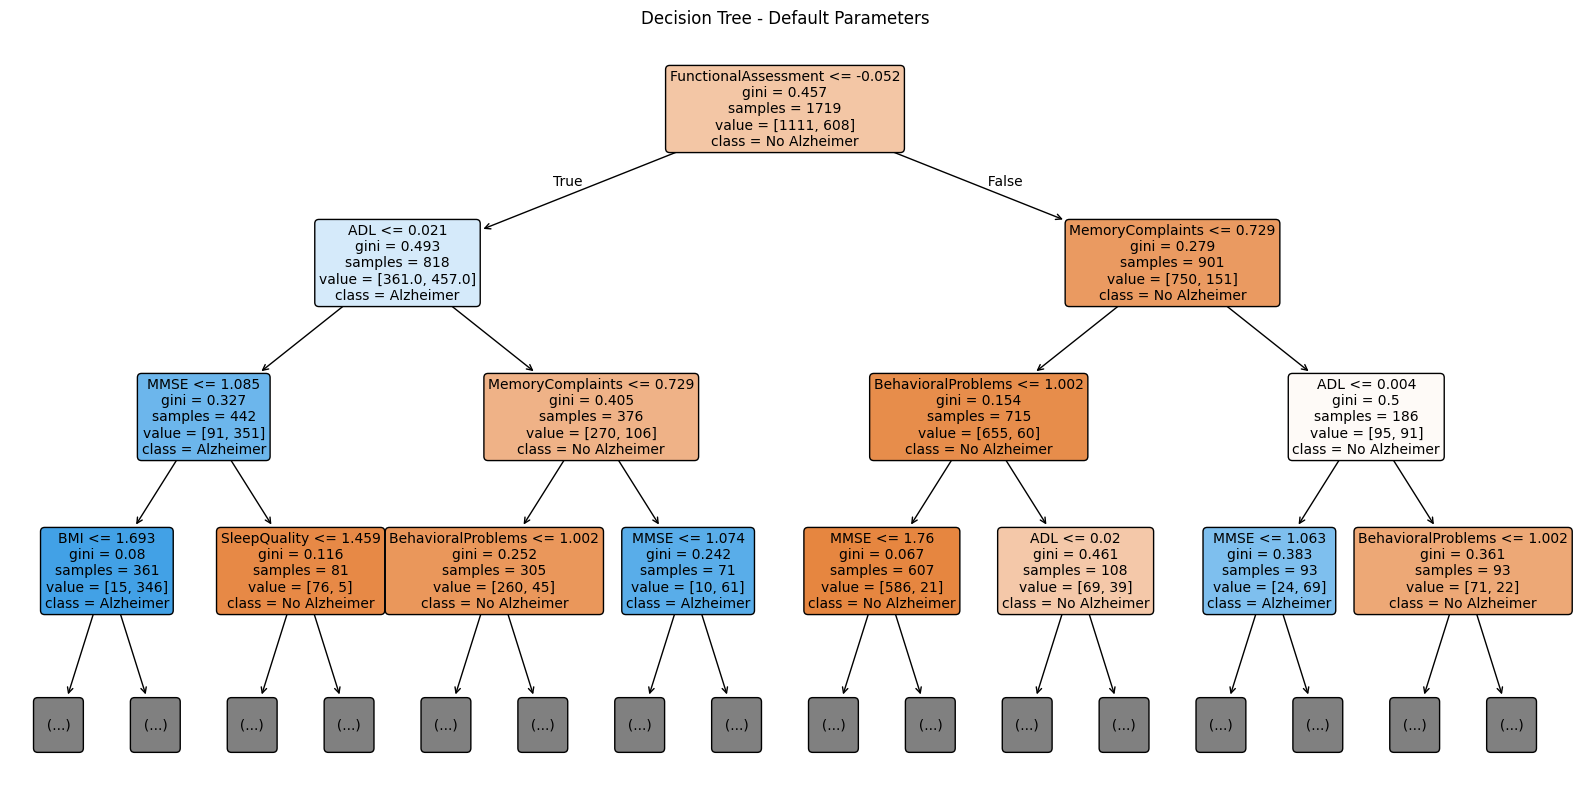

In [73]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_default, 
          feature_names=X.columns,
          class_names=['No Alzheimer', 'Alzheimer'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree - Default Parameters')
plt.show()

#### Обучение модели с подобранными эффективными гиперпараметрами

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)

print(f'Лучшие параметры: {dt_grid.best_params_}')
print(f'Лучший F1-score на CV: {dt_grid.best_score_:.4f}')

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучший F1-score на CV: 0.9430


In [ ]:
dt_best = dt_grid.best_estimator_
dt_best.fit(X_train_scaled, y_train)

# Предсказания
y_pred_train_dt = dt_best.predict(X_train_scaled)
y_prob_train_dt = dt_best.predict_proba(X_train_scaled)[:, 1]
y_pred_test_dt = dt_best.predict(X_test_scaled)
y_prob_test_dt = dt_best.predict_proba(X_test_scaled)[:, 1]

# Метрики для обучающего множества
accuracy_train_dt = accuracy_score(y_train, y_pred_train_dt)
precision_macro_train_dt = precision_score(y_train, y_pred_train_dt, average='macro')
precision_micro_train_dt = precision_score(y_train, y_pred_train_dt, average='micro')
recall_macro_train_dt = recall_score(y_train, y_pred_train_dt, average='macro')
recall_micro_train_dt = recall_score(y_train, y_pred_train_dt, average='micro')
f1_macro_train_dt = f1_score(y_train, y_pred_train_dt, average='macro')
f1_micro_train_dt = f1_score(y_train, y_pred_train_dt, average='micro')
roc_auc_train_dt = roc_auc_score(y_train, y_prob_train_dt)

print('Метрики для обучающего множества:')
print(f'Accuracy:           {accuracy_train_dt:.4f}')
print(f'Precision (macro):  {precision_macro_train_dt:.4f}')
print(f'Precision (micro):  {precision_micro_train_dt:.4f}')
print(f'Recall (macro):     {recall_macro_train_dt:.4f}')
print(f'Recall (micro):     {recall_micro_train_dt:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_dt:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_dt:.4f}')
print(f'ROC-AUC:           {roc_auc_train_dt:.4f}')

# Метрики для тестового множества
accuracy_test_dt = accuracy_score(y_test, y_pred_test_dt)
precision_macro_test_dt = precision_score(y_test, y_pred_test_dt, average='macro')
precision_micro_test_dt = precision_score(y_test, y_pred_test_dt, average='micro')
recall_macro_test_dt = recall_score(y_test, y_pred_test_dt, average='macro')
recall_micro_test_dt = recall_score(y_test, y_pred_test_dt, average='micro')
f1_macro_test_dt = f1_score(y_test, y_pred_test_dt, average='macro')
f1_micro_test_dt = f1_score(y_test, y_pred_test_dt, average='micro')
roc_auc_test_dt = roc_auc_score(y_test, y_prob_test_dt)

print('\nМетрики для тестового множества:')
print(f'Accuracy:           {accuracy_test_dt:.4f}')
print(f'Precision (macro):  {precision_macro_test_dt:.4f}')
print(f'Precision (micro):  {precision_micro_test_dt:.4f}')
print(f'Recall (macro):     {recall_macro_test_dt:.4f}')
print(f'Recall (micro):     {recall_micro_test_dt:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_dt:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_dt:.4f}')
print(f'ROC-AUC:           {roc_auc_test_dt:.4f}')

print('=' * 50)
print(classification_report(y_test, y_pred_test_dt))

ОБУЧАЮЩЕЕ МНОЖЕСТВО:
Accuracy:           0.9575
Precision (macro):  0.9557
Precision (micro):  0.9575
Recall (macro):     0.9511
Recall (micro):     0.9575
F1-Score (macro):   0.9533
F1-Score (micro):   0.9575
ROC-AUC:           0.9823

ТЕСТОВОЕ МНОЖЕСТВО:
Accuracy:           0.9512
Precision (macro):  0.9498
Precision (micro):  0.9512
Recall (macro):     0.9428
Recall (micro):     0.9512
F1-Score (macro):   0.9462
F1-Score (micro):   0.9512
ROC-AUC:           0.9454
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       278
           1       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



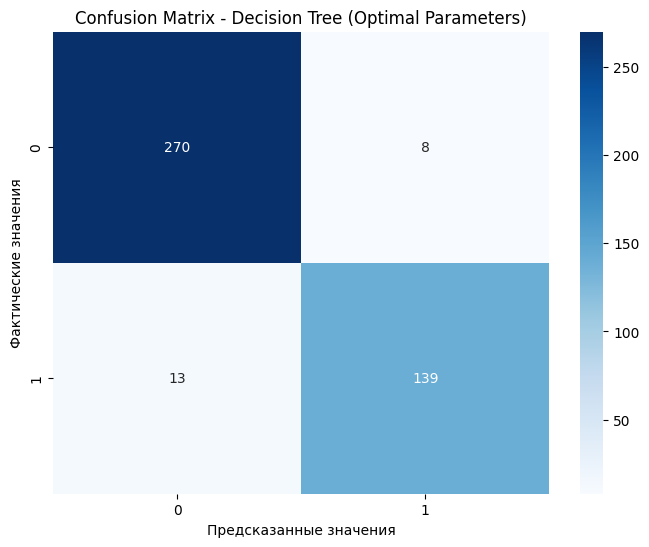

In [87]:
plt.figure(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, y_pred_test_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - Decision Tree (Optimal Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

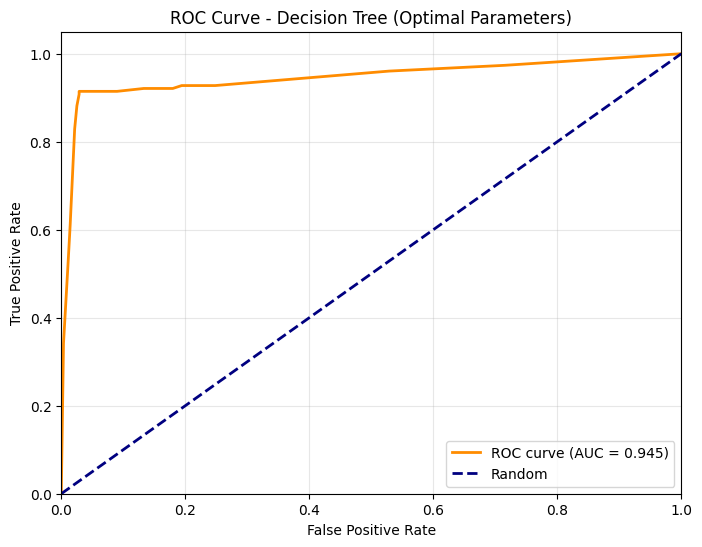

In [ ]:
plt.figure(figsize=(8, 6))
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_test_dt)
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_dt:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree (Optimal Parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

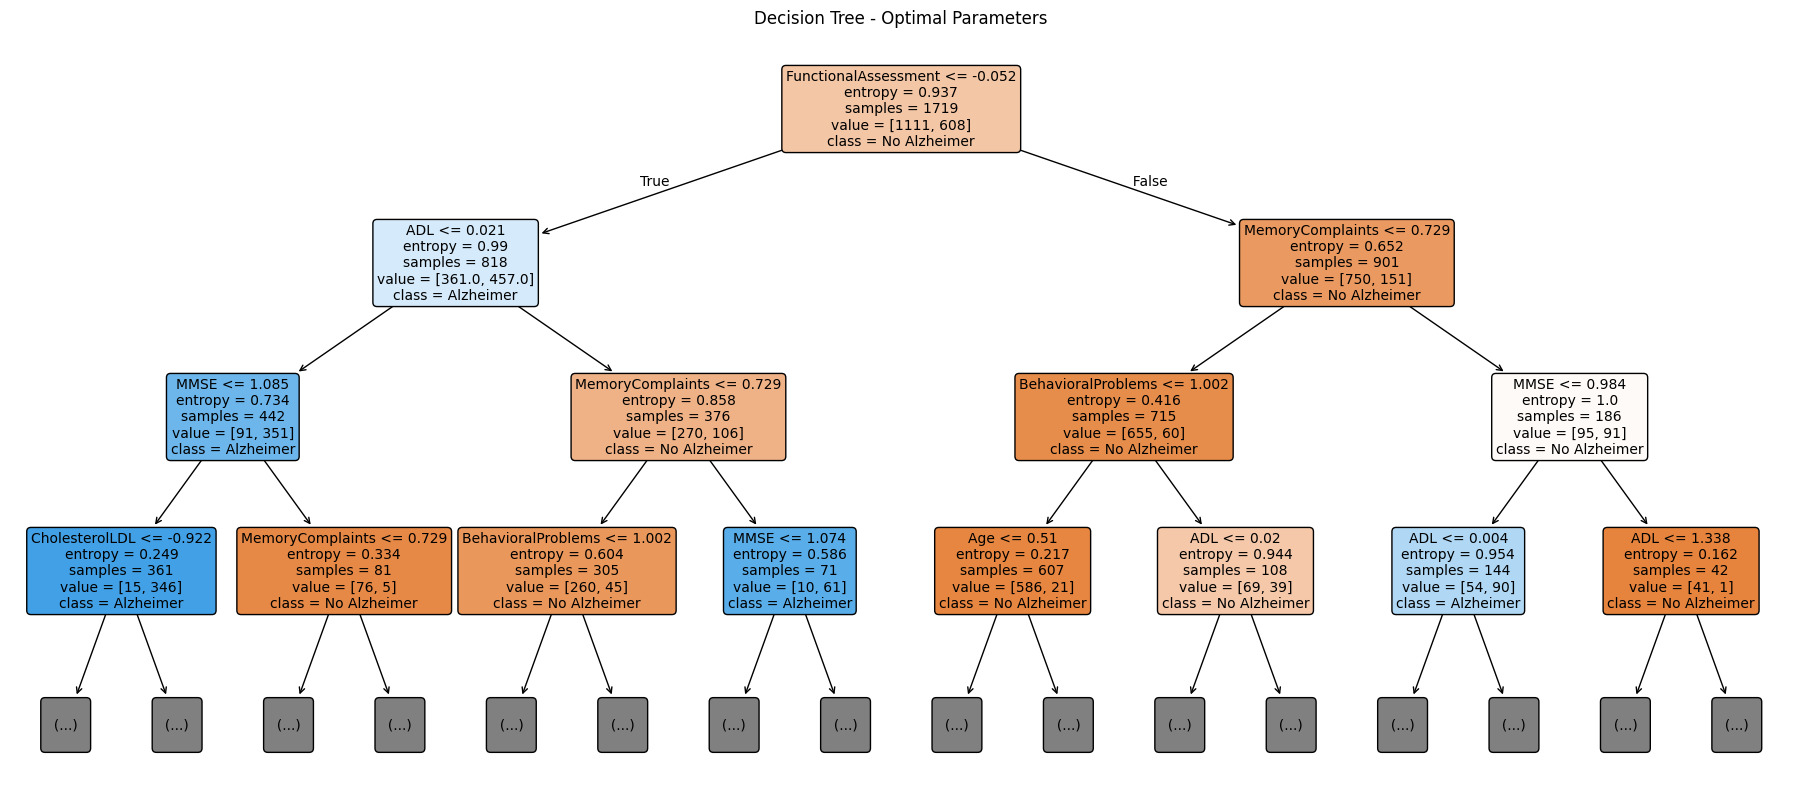

In [89]:
plt.figure(figsize=(23, 10))
plot_tree(dt_best, 
          feature_names=X.columns,
          class_names=['No Alzheimer', 'Alzheimer'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree - Optimal Parameters')
plt.show()

Построенное дерево с параметрами по-умолчанию имеет довольно низкие метрики как в обучающем, так и в тестовом множествах. Качество модели низкое, очень много случаев, когда модель предсказывает отсутствие болезни, когда в действительности она есть. После подбора эффективных гиперпараметров модель стала показывать гораздо лучшие результаты.

**Обучающее множество**
| Метрика | С подбором параметров | Без подбора параметров | Разница |
|---------|----------------------|-----------------------|---------|
| Accuracy | 0.9575 | 0.7109 | +0.2466 |
| Precision (macro) | 0.9557 | 0.6922 | +0.2635 |
| Precision (micro) | 0.9575 | 0.7109 | +0.2466 |
| Recall (macro) | 0.9511 | 0.6348 | +0.3163 |
| Recall (micro) | 0.9575 | 0.7109 | +0.2466 |
| F1-Score (macro) | 0.9533 | 0.6392 | +0.3141 |
| F1-Score (micro) | 0.9575 | 0.7109 | +0.2466 |
| ROC-AUC | 0.9823 | 0.6348 | +0.3475 |

**Тестовое множество**

| Метрика | С подбором параметров | Без подбора параметров | Разница |
|---------|----------------------|-----------------------|---------|
| Accuracy | 0.9512 | 0.6744 | +0.2768 |
| Precision (macro) | 0.9498 | 0.6348 | +0.3150 |
| Precision (micro) | 0.9512 | 0.6744 | +0.2768 |
| Recall (macro) | 0.9428 | 0.5976 | +0.3452 |
| Recall (micro) | 0.9512 | 0.6744 | +0.2768 |
| F1-Score (macro) | 0.9462 | 0.5975 | +0.3487 |
| F1-Score (micro) | 0.9512 | 0.6744 | +0.2768 |
| ROC-AUC | 0.9454 | 0.5976 | +0.3478 |

**Выводы**

- **Значительное улучшение всех метрик** после подбора гиперпараметров
- **Наибольший прирост**: ROC-AUC (+0.3475 на train, +0.3478 на test)
- **Модель с подбором параметров** демонстрирует отличное качество (>0.94 по всем основным метрикам)
- **Модель без подбора** показывает средние результаты (~0.60-0.70)
- **Отсутствие переобучения** - метрики на train и test близки у настроенной модели         



### Линейный дискриминантный анализ (Linear Discriminant Analysis)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda_default = LinearDiscriminantAnalysis()
lda_default.fit(X_train_selected, y_train)

# Предсказания
y_pred_train_lda_default = lda_default.predict(X_train_selected)
y_prob_train_lda_default = lda_default.predict_proba(X_train_selected)[:, 1]
y_pred_test_lda_default = lda_default.predict(X_test_selected)
y_prob_test_lda_default = lda_default.predict_proba(X_test_selected)[:, 1]

# Метрики для обучающего множества
accuracy_train_lda_default = accuracy_score(y_train, y_pred_train_lda_default)
precision_macro_train_lda_default = precision_score(y_train, y_pred_train_lda_default, average='macro')
precision_micro_train_lda_default = precision_score(y_train, y_pred_train_lda_default, average='micro')
recall_macro_train_lda_default = recall_score(y_train, y_pred_train_lda_default, average='macro')
recall_micro_train_lda_default = recall_score(y_train, y_pred_train_lda_default, average='micro')
f1_macro_train_lda_default = f1_score(y_train, y_pred_train_lda_default, average='macro')
f1_micro_train_lda_default = f1_score(y_train, y_pred_train_lda_default, average='micro')
roc_auc_train_lda_default = roc_auc_score(y_train, y_prob_train_lda_default)

print('Метрики для обучающего множества:')
print(f'Accuracy:           {accuracy_train_lda_default:.4f}')
print(f'Precision (macro):  {precision_macro_train_lda_default:.4f}')
print(f'Precision (micro):  {precision_micro_train_lda_default:.4f}')
print(f'Recall (macro):     {recall_macro_train_lda_default:.4f}')
print(f'Recall (micro):     {recall_micro_train_lda_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_lda_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_lda_default:.4f}')
print(f'ROC-AUC:           {roc_auc_train_lda_default:.4f}')

# Метрики для тестового множества
accuracy_test_lda_default = accuracy_score(y_test, y_pred_test_lda_default)
precision_macro_test_lda_default = precision_score(y_test, y_pred_test_lda_default, average='macro')
precision_micro_test_lda_default = precision_score(y_test, y_pred_test_lda_default, average='micro')
recall_macro_test_lda_default = recall_score(y_test, y_pred_test_lda_default, average='macro')
recall_micro_test_lda_default = recall_score(y_test, y_pred_test_lda_default, average='micro')
f1_macro_test_lda_default = f1_score(y_test, y_pred_test_lda_default, average='macro')
f1_micro_test_lda_default = f1_score(y_test, y_pred_test_lda_default, average='micro')
roc_auc_test_lda_default = roc_auc_score(y_test, y_prob_test_lda_default)

print('\nМетрики для тестового множества:')
print(f'Accuracy:           {accuracy_test_lda_default:.4f}')
print(f'Precision (macro):  {precision_macro_test_lda_default:.4f}')
print(f'Precision (micro):  {precision_micro_test_lda_default:.4f}')
print(f'Recall (macro):     {recall_macro_test_lda_default:.4f}')
print(f'Recall (micro):     {recall_micro_test_lda_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_lda_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_lda_default:.4f}')
print(f'ROC-AUC:           {roc_auc_test_lda_default:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_test_lda_default))

Метрики для обучающего множества:
Accuracy:           0.8470
Precision (macro):  0.8364
Precision (micro):  0.8470
Recall (macro):     0.8247
Recall (micro):     0.8470
F1-Score (macro):   0.8298
F1-Score (micro):   0.8470
ROC-AUC:           0.9090

Метрики для тестового множества:
Accuracy:           0.8163
Precision (macro):  0.7992
Precision (micro):  0.8163
Recall (macro):     0.7983
Recall (micro):     0.8163
F1-Score (macro):   0.7987
F1-Score (micro):   0.8163
ROC-AUC:           0.8830
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



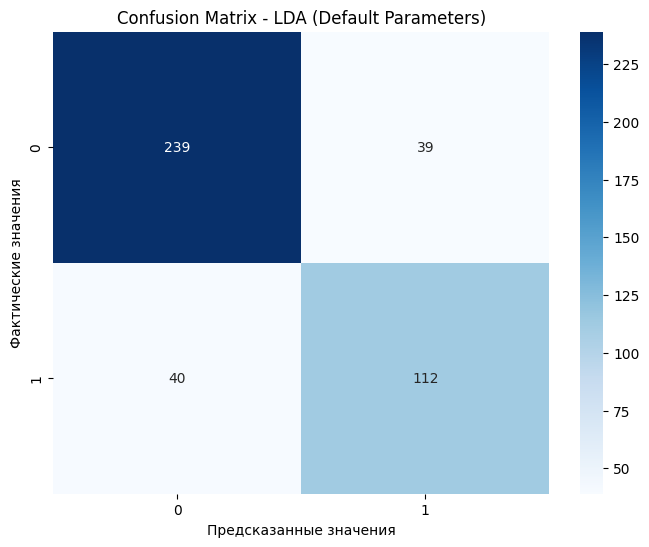

In [91]:
plt.figure(figsize=(8, 6))
cm_lda_default = confusion_matrix(y_test, y_pred_test_lda_default)
sns.heatmap(cm_lda_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - LDA (Default Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

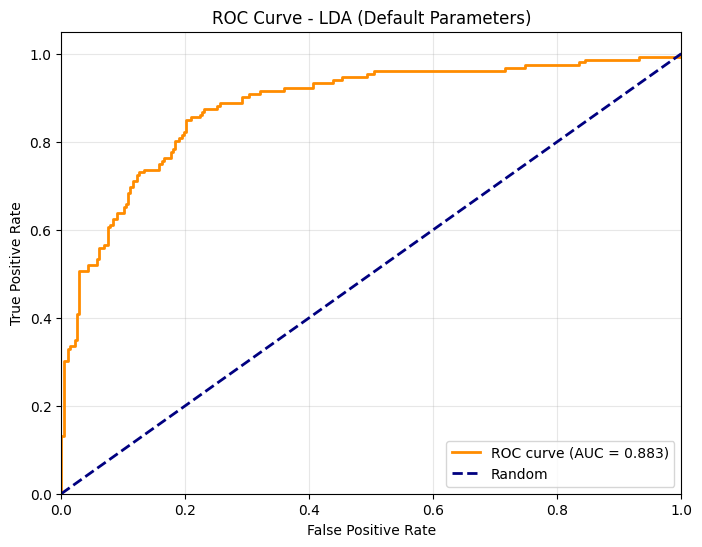

In [ ]:
plt.figure(figsize=(8, 6))
fpr_lda_default, tpr_lda_default, _ = roc_curve(y_test, y_prob_test_lda_default)
plt.plot(fpr_lda_default, tpr_lda_default, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_lda_default:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LDA (Default Parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

#### Обучение модели с подобранными эффективными гиперпараметрами

In [97]:
param_grid_lda = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.5, 0.9]
}

lda_grid = GridSearchCV(
    LinearDiscriminantAnalysis(),
    param_grid_lda,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

lda_grid.fit(X_train_selected, y_train)

print(f'Лучшие параметры: {lda_grid.best_params_}')
print(f'Лучший F1-score на CV: {lda_grid.best_score_:.4f}')

Лучшие параметры: {'shrinkage': None, 'solver': 'svd'}
Лучший F1-score на CV: 0.8285


In [98]:
lda_best = lda_grid.best_estimator_
lda_best.fit(X_train_selected, y_train)

# Предсказания
y_pred_train_lda = lda_best.predict(X_train_selected)
y_prob_train_lda = lda_best.predict_proba(X_train_selected)[:, 1]
y_pred_test_lda = lda_best.predict(X_test_selected)
y_prob_test_lda = lda_best.predict_proba(X_test_selected)[:, 1]

# Метрики для обучающего множества
accuracy_train_lda = accuracy_score(y_train, y_pred_train_lda)
precision_macro_train_lda = precision_score(y_train, y_pred_train_lda, average='macro')
precision_micro_train_lda = precision_score(y_train, y_pred_train_lda, average='micro')
recall_macro_train_lda = recall_score(y_train, y_pred_train_lda, average='macro')
recall_micro_train_lda = recall_score(y_train, y_pred_train_lda, average='micro')
f1_macro_train_lda = f1_score(y_train, y_pred_train_lda, average='macro')
f1_micro_train_lda = f1_score(y_train, y_pred_train_lda, average='micro')
roc_auc_train_lda = roc_auc_score(y_train, y_prob_train_lda)

print('Метрики для обучающего множества:')
print(f'Accuracy:           {accuracy_train_lda:.4f}')
print(f'Precision (macro):  {precision_macro_train_lda:.4f}')
print(f'Precision (micro):  {precision_micro_train_lda:.4f}')
print(f'Recall (macro):     {recall_macro_train_lda:.4f}')
print(f'Recall (micro):     {recall_micro_train_lda:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_lda:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_lda:.4f}')
print(f'ROC-AUC:           {roc_auc_train_lda:.4f}')

# Метрики для тестового множества
accuracy_test_lda = accuracy_score(y_test, y_pred_test_lda)
precision_macro_test_lda = precision_score(y_test, y_pred_test_lda, average='macro')
precision_micro_test_lda = precision_score(y_test, y_pred_test_lda, average='micro')
recall_macro_test_lda = recall_score(y_test, y_pred_test_lda, average='macro')
recall_micro_test_lda = recall_score(y_test, y_pred_test_lda, average='micro')
f1_macro_test_lda = f1_score(y_test, y_pred_test_lda, average='macro')
f1_micro_test_lda = f1_score(y_test, y_pred_test_lda, average='micro')
roc_auc_test_lda = roc_auc_score(y_test, y_prob_test_lda)

print('\nМетрики для тестового множества:')
print(f'Accuracy:           {accuracy_test_lda:.4f}')
print(f'Precision (macro):  {precision_macro_test_lda:.4f}')
print(f'Precision (micro):  {precision_micro_test_lda:.4f}')
print(f'Recall (macro):     {recall_macro_test_lda:.4f}')
print(f'Recall (micro):     {recall_micro_test_lda:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_lda:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_lda:.4f}')
print(f'ROC-AUC:           {roc_auc_test_lda:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_test_lda))

Метрики для обучающего множества:
Accuracy:           0.8470
Precision (macro):  0.8364
Precision (micro):  0.8470
Recall (macro):     0.8247
Recall (micro):     0.8470
F1-Score (macro):   0.8298
F1-Score (micro):   0.8470
ROC-AUC:           0.9090

Метрики для тестового множества:
Accuracy:           0.8163
Precision (macro):  0.7992
Precision (micro):  0.8163
Recall (macro):     0.7983
Recall (micro):     0.8163
F1-Score (macro):   0.7987
F1-Score (micro):   0.8163
ROC-AUC:           0.8830
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       278
           1       0.74      0.74      0.74       152

    accuracy                           0.82       430
   macro avg       0.80      0.80      0.80       430
weighted avg       0.82      0.82      0.82       430



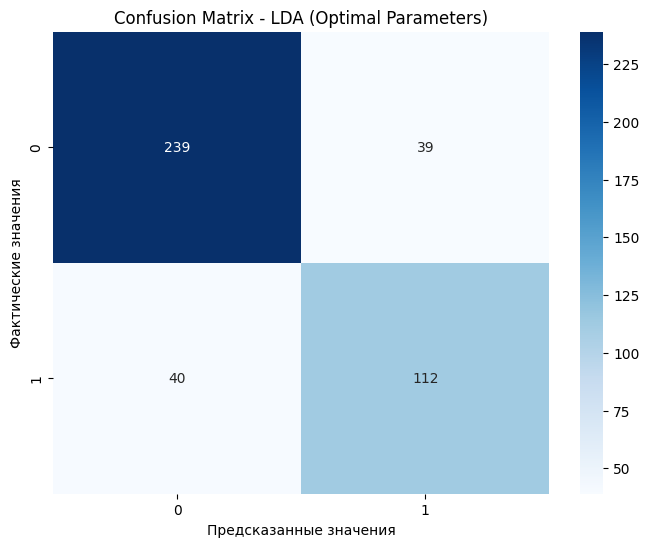

In [99]:
plt.figure(figsize=(8, 6))
cm_lda = confusion_matrix(y_test, y_pred_test_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - LDA (Optimal Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

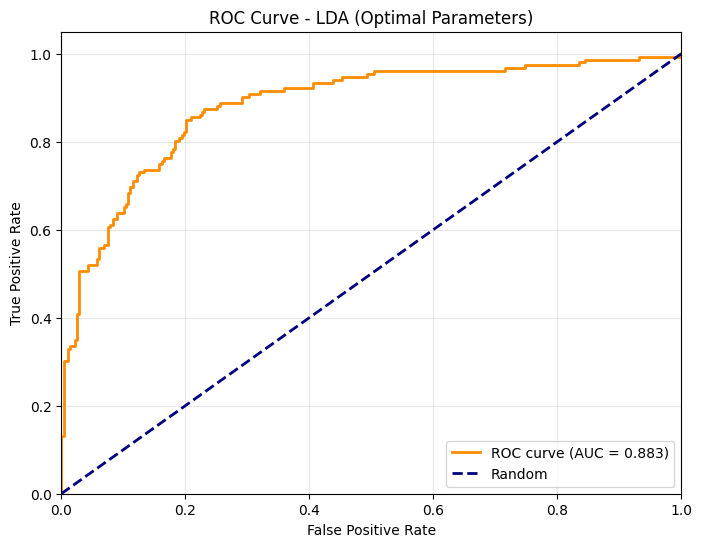

In [ ]:
plt.figure(figsize=(8, 6))
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_test_lda)
plt.plot(fpr_lda, tpr_lda, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_lda:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LDA (Optimal Parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
comparison_data_lda = {
    'Метрика': [
        'Accuracy', 'Precision (macro)', 'Precision (micro)', 
        'Recall (macro)', 'Recall (micro)', 'F1-Score (macro)', 
        'F1-Score (micro)', 'ROC-AUC'
    ],
    'Default_Train': [
        accuracy_train_lda_default, precision_macro_train_lda_default,
        precision_micro_train_lda_default, recall_macro_train_lda_default,
        recall_micro_train_lda_default, f1_macro_train_lda_default,
        f1_micro_train_lda_default, roc_auc_train_lda_default
    ],
    'Best_Train': [
        accuracy_train_lda, precision_macro_train_lda,
        precision_micro_train_lda, recall_macro_train_lda,
        recall_micro_train_lda, f1_macro_train_lda,
        f1_micro_train_lda, roc_auc_train_lda
    ],
    'Default_Test': [
        accuracy_test_lda_default, precision_macro_test_lda_default,
        precision_micro_test_lda_default, recall_macro_test_lda_default,
        recall_micro_test_lda_default, f1_macro_test_lda_default,
        f1_micro_test_lda_default, roc_auc_test_lda_default
    ],
    'Best_Test': [
        accuracy_test_lda, precision_macro_test_lda,
        precision_micro_test_lda, recall_macro_test_lda,
        recall_micro_test_lda, f1_macro_test_lda,
        f1_micro_test_lda, roc_auc_test_lda
    ]
}

comparison_df_lda = pd.DataFrame(comparison_data_lda)
comparison_df_lda['Train_Diff'] = comparison_df_lda['Best_Train'] - comparison_df_lda['Default_Train']
comparison_df_lda['Test_Diff'] = comparison_df_lda['Best_Test'] - comparison_df_lda['Default_Test']

print('Сравнение метрик:')
print(comparison_df_lda.round(4))

Сравнение метрик:
             Метрика  Default_Train  Best_Train  Default_Test  Best_Test  \
0           Accuracy           0.85        0.85          0.82       0.82   
1  Precision (macro)           0.84        0.84          0.80       0.80   
2  Precision (micro)           0.85        0.85          0.82       0.82   
3     Recall (macro)           0.82        0.82          0.80       0.80   
4     Recall (micro)           0.85        0.85          0.82       0.82   
5   F1-Score (macro)           0.83        0.83          0.80       0.80   
6   F1-Score (micro)           0.85        0.85          0.82       0.82   
7            ROC-AUC           0.91        0.91          0.88       0.88   

   Train_Diff  Test_Diff  
0        0.00       0.00  
1        0.00       0.00  
2        0.00       0.00  
3        0.00       0.00  
4        0.00       0.00  
5        0.00       0.00  
6        0.00       0.00  
7        0.00       0.00  


Модель показывает средние результаты и справляется хуже, чем модели, построенные **Наивным Байесовским классификатором** и **Деревом решений**. Подбор оптимальных гиперпараметров не улучшил качество модели. Однако во всех случаях переобучение модели не критично.

### Метод опорных векторов (Support Vector Machines)

In [ ]:
from sklearn.svm import SVC

svm_default = SVC(probability=True, random_state=42)
svm_default.fit(X_train_selected, y_train)

# Предсказания
y_pred_train_svm_default = svm_default.predict(X_train_selected)
y_prob_train_svm_default = svm_default.predict_proba(X_train_selected)[:, 1]
y_pred_test_svm_default = svm_default.predict(X_test_selected)
y_prob_test_svm_default = svm_default.predict_proba(X_test_selected)[:, 1]

# Метрики для обучающего множества
accuracy_train_svm_default = accuracy_score(y_train, y_pred_train_svm_default)
precision_macro_train_svm_default = precision_score(y_train, y_pred_train_svm_default, average='macro')
precision_micro_train_svm_default = precision_score(y_train, y_pred_train_svm_default, average='micro')
recall_macro_train_svm_default = recall_score(y_train, y_pred_train_svm_default, average='macro')
recall_micro_train_svm_default = recall_score(y_train, y_pred_train_svm_default, average='micro')
f1_macro_train_svm_default = f1_score(y_train, y_pred_train_svm_default, average='macro')
f1_micro_train_svm_default = f1_score(y_train, y_pred_train_svm_default, average='micro')
roc_auc_train_svm_default = roc_auc_score(y_train, y_prob_train_svm_default)

print('Метрики для обучающего множества:')
print(f'Accuracy:           {accuracy_train_svm_default:.4f}')
print(f'Precision (macro):  {precision_macro_train_svm_default:.4f}')
print(f'Precision (micro):  {precision_micro_train_svm_default:.4f}')
print(f'Recall (macro):     {recall_macro_train_svm_default:.4f}')
print(f'Recall (micro):     {recall_micro_train_svm_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_svm_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_svm_default:.4f}')
print(f'ROC-AUC:           {roc_auc_train_svm_default:.4f}')

# Метрики для тестового множества
accuracy_test_svm_default = accuracy_score(y_test, y_pred_test_svm_default)
precision_macro_test_svm_default = precision_score(y_test, y_pred_test_svm_default, average='macro')
precision_micro_test_svm_default = precision_score(y_test, y_pred_test_svm_default, average='micro')
recall_macro_test_svm_default = recall_score(y_test, y_pred_test_svm_default, average='macro')
recall_micro_test_svm_default = recall_score(y_test, y_pred_test_svm_default, average='micro')
f1_macro_test_svm_default = f1_score(y_test, y_pred_test_svm_default, average='macro')
f1_micro_test_svm_default = f1_score(y_test, y_pred_test_svm_default, average='micro')
roc_auc_test_svm_default = roc_auc_score(y_test, y_prob_test_svm_default)

print('\nМетрики для тестового множества:')
print(f'Accuracy:           {accuracy_test_svm_default:.4f}')
print(f'Precision (macro):  {precision_macro_test_svm_default:.4f}')
print(f'Precision (micro):  {precision_micro_test_svm_default:.4f}')
print(f'Recall (macro):     {recall_macro_test_svm_default:.4f}')
print(f'Recall (micro):     {recall_micro_test_svm_default:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_svm_default:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_svm_default:.4f}')
print(f'ROC-AUC:           {roc_auc_test_svm_default:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_test_svm_default))

Метрики для обучающего множества:
Accuracy:           0.9139
Precision (macro):  0.9142
Precision (micro):  0.9139
Recall (macro):     0.8958
Recall (micro):     0.9139
F1-Score (macro):   0.9038
F1-Score (micro):   0.9139
ROC-AUC:           0.9572

Метрики для тестового множества:
Accuracy:           0.8930
Precision (macro):  0.8893
Precision (micro):  0.8930
Recall (macro):     0.8740
Recall (micro):     0.8930
F1-Score (macro):   0.8807
F1-Score (micro):   0.8930
ROC-AUC:           0.9280
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       278
           1       0.88      0.81      0.84       152

    accuracy                           0.89       430
   macro avg       0.89      0.87      0.88       430
weighted avg       0.89      0.89      0.89       430



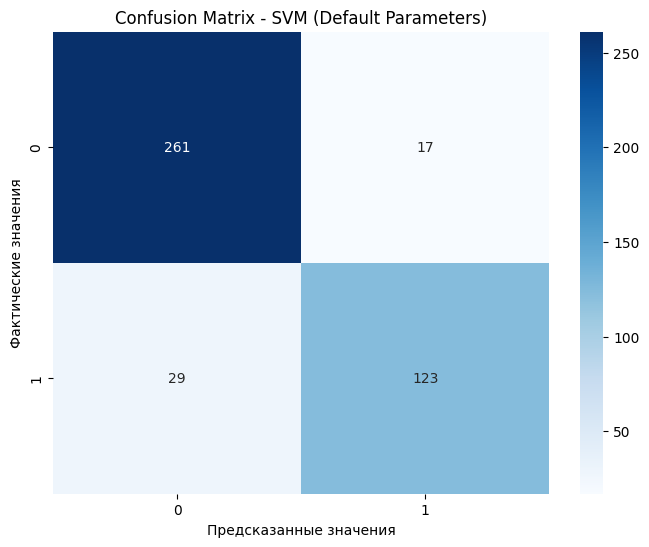

In [103]:
plt.figure(figsize=(8, 6))
cm_svm_default = confusion_matrix(y_test, y_pred_test_svm_default)
sns.heatmap(cm_svm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - SVM (Default Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

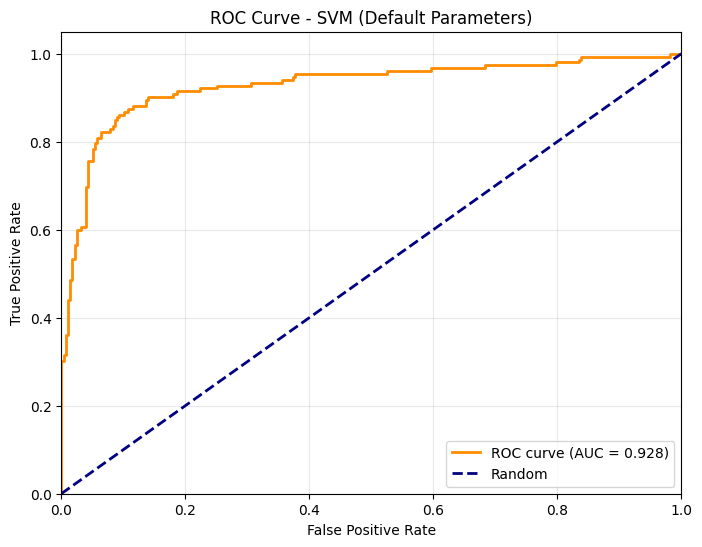

In [ ]:
plt.figure(figsize=(8, 6))
fpr_svm_default, tpr_svm_default, _ = roc_curve(y_test, y_prob_test_svm_default)
plt.plot(fpr_svm_default, tpr_svm_default, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_svm_default:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (Default Parameters)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

#### Обучение модели с подобранными эффективными гиперпараметрами

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1, 1]
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=3, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_selected, y_train)

print(f'Лучшие параметры: {svm_grid.best_params_}')
print(f'Лучший F1-score на CV: {svm_grid.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Лучшие параметры: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Лучший F1-score на CV: 0.8592


In [ ]:
svm_best = svm_grid.best_estimator_
svm_best.fit(X_train_selected, y_train)

# Предсказания
y_pred_train_svm = svm_best.predict(X_train_selected)
y_prob_train_svm = svm_best.predict_proba(X_train_selected)[:, 1]
y_pred_test_svm = svm_best.predict(X_test_selected)
y_prob_test_svm = svm_best.predict_proba(X_test_selected)[:, 1]

# Метрики для обучающего множества
accuracy_train_svm = accuracy_score(y_train, y_pred_train_svm)
precision_macro_train_svm = precision_score(y_train, y_pred_train_svm, average='macro')
precision_micro_train_svm = precision_score(y_train, y_pred_train_svm, average='micro')
recall_macro_train_svm = recall_score(y_train, y_pred_train_svm, average='macro')
recall_micro_train_svm = recall_score(y_train, y_pred_train_svm, average='micro')
f1_macro_train_svm = f1_score(y_train, y_pred_train_svm, average='macro')
f1_micro_train_svm = f1_score(y_train, y_pred_train_svm, average='micro')
roc_auc_train_svm = roc_auc_score(y_train, y_prob_train_svm)

print('Метрики для обучающего множества:')
print(f'Accuracy:           {accuracy_train_svm:.4f}')
print(f'Precision (macro):  {precision_macro_train_svm:.4f}')
print(f'Precision (micro):  {precision_micro_train_svm:.4f}')
print(f'Recall (macro):     {recall_macro_train_svm:.4f}')
print(f'Recall (micro):     {recall_micro_train_svm:.4f}')
print(f'F1-Score (macro):   {f1_macro_train_svm:.4f}')
print(f'F1-Score (micro):   {f1_micro_train_svm:.4f}')
print(f'ROC-AUC:           {roc_auc_train_svm:.4f}')

# Метрики для тестового множества
accuracy_test_svm = accuracy_score(y_test, y_pred_test_svm)
precision_macro_test_svm = precision_score(y_test, y_pred_test_svm, average='macro')
precision_micro_test_svm = precision_score(y_test, y_pred_test_svm, average='micro')
recall_macro_test_svm = recall_score(y_test, y_pred_test_svm, average='macro')
recall_micro_test_svm = recall_score(y_test, y_pred_test_svm, average='micro')
f1_macro_test_svm = f1_score(y_test, y_pred_test_svm, average='macro')
f1_micro_test_svm = f1_score(y_test, y_pred_test_svm, average='micro')
roc_auc_test_svm = roc_auc_score(y_test, y_prob_test_svm)

print('\nМетрики для тестового множества:')
print(f'Accuracy:           {accuracy_test_svm:.4f}')
print(f'Precision (macro):  {precision_macro_test_svm:.4f}')
print(f'Precision (micro):  {precision_micro_test_svm:.4f}')
print(f'Recall (macro):     {recall_macro_test_svm:.4f}')
print(f'Recall (micro):     {recall_micro_test_svm:.4f}')
print(f'F1-Score (macro):   {f1_macro_test_svm:.4f}')
print(f'F1-Score (micro):   {f1_micro_test_svm:.4f}')
print(f'ROC-AUC:           {roc_auc_test_svm:.4f}')

print('=' * 53)
print(classification_report(y_test, y_pred_test_svm))

Метрики для обучающего множества:
Accuracy:           0.9593
Precision (macro):  0.9567
Precision (micro):  0.9593
Recall (macro):     0.9540
Recall (micro):     0.9593
F1-Score (macro):   0.9553
F1-Score (micro):   0.9593
ROC-AUC:           0.9809

Метрики для тестового множества:
Accuracy:           0.8837
Precision (macro):  0.8715
Precision (micro):  0.8837
Recall (macro):     0.8758
Recall (micro):     0.8837
F1-Score (macro):   0.8735
F1-Score (micro):   0.8837
ROC-AUC:           0.9286
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       278
           1       0.83      0.85      0.84       152

    accuracy                           0.88       430
   macro avg       0.87      0.88      0.87       430
weighted avg       0.88      0.88      0.88       430



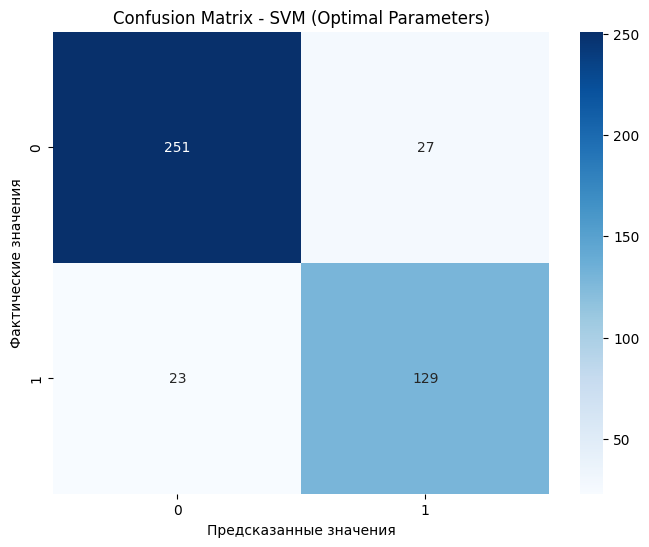

In [108]:
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_test_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - SVM (Optimal Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

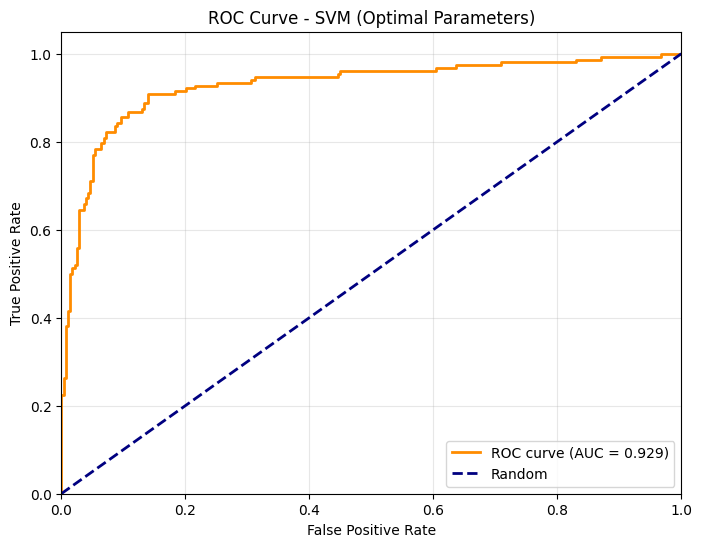

In [109]:
plt.figure(figsize=(8, 6))
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_test_svm)
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_svm:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (Optimal Parameters)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [110]:
# Создаем DataFrame для сравнения
comparison_data_svm = {
    'Метрика': [
        'Accuracy', 'Precision (macro)', 'Precision (micro)', 
        'Recall (macro)', 'Recall (micro)', 'F1-Score (macro)', 
        'F1-Score (micro)', 'ROC-AUC'
    ],
    'Default_Train': [
        accuracy_train_svm_default, precision_macro_train_svm_default,
        precision_micro_train_svm_default, recall_macro_train_svm_default,
        recall_micro_train_svm_default, f1_macro_train_svm_default,
        f1_micro_train_svm_default, roc_auc_train_svm_default
    ],
    'Best_Train': [
        accuracy_train_svm, precision_macro_train_svm,
        precision_micro_train_svm, recall_macro_train_svm,
        recall_micro_train_svm, f1_macro_train_svm,
        f1_micro_train_svm, roc_auc_train_svm
    ],
    'Default_Test': [
        accuracy_test_svm_default, precision_macro_test_svm_default,
        precision_micro_test_svm_default, recall_macro_test_svm_default,
        recall_micro_test_svm_default, f1_macro_test_svm_default,
        f1_micro_test_svm_default, roc_auc_test_svm_default
    ],
    'Best_Test': [
        accuracy_test_svm, precision_macro_test_svm,
        precision_micro_test_svm, recall_macro_test_svm,
        recall_micro_test_svm, f1_macro_test_svm,
        f1_micro_test_svm, roc_auc_test_svm
    ]
}

comparison_df_svm = pd.DataFrame(comparison_data_svm)
comparison_df_svm['Train_Diff'] = comparison_df_svm['Best_Train'] - comparison_df_svm['Default_Train']
comparison_df_svm['Test_Diff'] = comparison_df_svm['Best_Test'] - comparison_df_svm['Default_Test']

print("Сравнение метрик:")
print(comparison_df_svm.round(4))

Сравнение метрик:
             Метрика  Default_Train  Best_Train  Default_Test  Best_Test  \
0           Accuracy           0.91        0.96          0.89       0.88   
1  Precision (macro)           0.91        0.96          0.89       0.87   
2  Precision (micro)           0.91        0.96          0.89       0.88   
3     Recall (macro)           0.90        0.95          0.87       0.88   
4     Recall (micro)           0.91        0.96          0.89       0.88   
5   F1-Score (macro)           0.90        0.96          0.88       0.87   
6   F1-Score (micro)           0.91        0.96          0.89       0.88   
7            ROC-AUC           0.96        0.98          0.93       0.93   

   Train_Diff  Test_Diff  
0        0.05      -0.01  
1        0.04      -0.02  
2        0.05      -0.01  
3        0.06       0.00  
4        0.05      -0.01  
5        0.05      -0.01  
6        0.05      -0.01  
7        0.02       0.00  


Метод показывает умеренное качество. После подбора гиперпараметров появилось небольшое переобучение. Качество модели не выросло, однако количество ложноположительных исходов уменьшилось. Подбор гиперпараметров более ресурсозатратный, чем в других методах.

### Метод ближайших соседей (k-Nearest Neighbors)

In [111]:
from sklearn.neighbors import KNeighborsClassifier

knn_default = KNeighborsClassifier()
knn_default.fit(X_train_selected, y_train)

# Предсказания
y_pred_train_knn_default = knn_default.predict(X_train_selected)
y_prob_train_knn_default = knn_default.predict_proba(X_train_selected)[:, 1]
y_pred_test_knn_default = knn_default.predict(X_test_selected)
y_prob_test_knn_default = knn_default.predict_proba(X_test_selected)[:, 1]

# Метрики для обучающего множества
accuracy_train_knn_default = accuracy_score(y_train, y_pred_train_knn_default)
precision_macro_train_knn_default = precision_score(y_train, y_pred_train_knn_default, average='macro')
precision_micro_train_knn_default = precision_score(y_train, y_pred_train_knn_default, average='micro')
recall_macro_train_knn_default = recall_score(y_train, y_pred_train_knn_default, average='macro')
recall_micro_train_knn_default = recall_score(y_train, y_pred_train_knn_default, average='micro')
f1_macro_train_knn_default = f1_score(y_train, y_pred_train_knn_default, average='macro')
f1_micro_train_knn_default = f1_score(y_train, y_pred_train_knn_default, average='micro')
roc_auc_train_knn_default = roc_auc_score(y_train, y_prob_train_knn_default)

print("Метрики для обучающего множества:")
print(f"Accuracy:           {accuracy_train_knn_default:.4f}")
print(f"Precision (macro):  {precision_macro_train_knn_default:.4f}")
print(f"Precision (micro):  {precision_micro_train_knn_default:.4f}")
print(f"Recall (macro):     {recall_macro_train_knn_default:.4f}")
print(f"Recall (micro):     {recall_micro_train_knn_default:.4f}")
print(f"F1-Score (macro):   {f1_macro_train_knn_default:.4f}")
print(f"F1-Score (micro):   {f1_micro_train_knn_default:.4f}")
print(f"ROC-AUC:           {roc_auc_train_knn_default:.4f}")

# Метрики для тестового множества
accuracy_test_knn_default = accuracy_score(y_test, y_pred_test_knn_default)
precision_macro_test_knn_default = precision_score(y_test, y_pred_test_knn_default, average='macro')
precision_micro_test_knn_default = precision_score(y_test, y_pred_test_knn_default, average='micro')
recall_macro_test_knn_default = recall_score(y_test, y_pred_test_knn_default, average='macro')
recall_micro_test_knn_default = recall_score(y_test, y_pred_test_knn_default, average='micro')
f1_macro_test_knn_default = f1_score(y_test, y_pred_test_knn_default, average='macro')
f1_micro_test_knn_default = f1_score(y_test, y_pred_test_knn_default, average='micro')
roc_auc_test_knn_default = roc_auc_score(y_test, y_prob_test_knn_default)

print("\nМетрики для тестового множества:")
print(f"Accuracy:           {accuracy_test_knn_default:.4f}")
print(f"Precision (macro):  {precision_macro_test_knn_default:.4f}")
print(f"Precision (micro):  {precision_micro_test_knn_default:.4f}")
print(f"Recall (macro):     {recall_macro_test_knn_default:.4f}")
print(f"Recall (micro):     {recall_micro_test_knn_default:.4f}")
print(f"F1-Score (macro):   {f1_macro_test_knn_default:.4f}")
print(f"F1-Score (micro):   {f1_micro_test_knn_default:.4f}")
print(f"ROC-AUC:           {roc_auc_test_knn_default:.4f}")

print("=" * 53)
print(classification_report(y_test, y_pred_test_knn_default))

Метрики для обучающего множества:
Accuracy:           0.9052
Precision (macro):  0.8960
Precision (micro):  0.9052
Recall (macro):     0.8969
Recall (micro):     0.9052
F1-Score (macro):   0.8964
F1-Score (micro):   0.9052
ROC-AUC:           0.9632

Метрики для тестового множества:
Accuracy:           0.8326
Precision (macro):  0.8168
Precision (micro):  0.8326
Recall (macro):     0.8168
Recall (micro):     0.8326
F1-Score (macro):   0.8168
F1-Score (micro):   0.8326
ROC-AUC:           0.8787
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       278
           1       0.76      0.76      0.76       152

    accuracy                           0.83       430
   macro avg       0.82      0.82      0.82       430
weighted avg       0.83      0.83      0.83       430



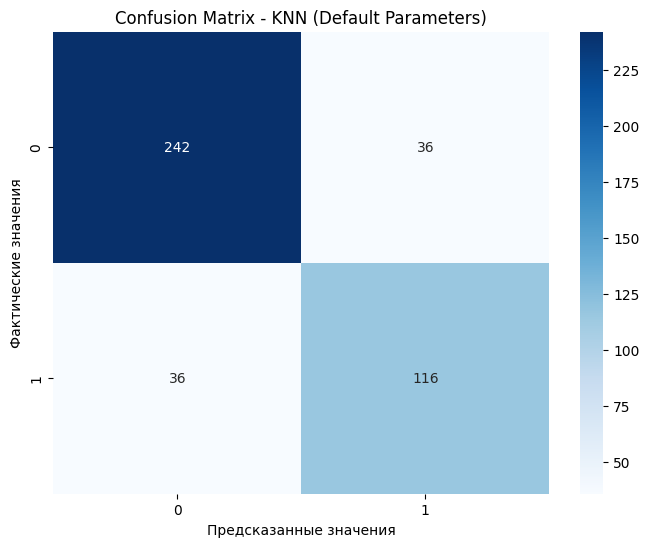

In [112]:
plt.figure(figsize=(8, 6))
cm_knn_default = confusion_matrix(y_test, y_pred_test_knn_default)
sns.heatmap(cm_knn_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - KNN (Default Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

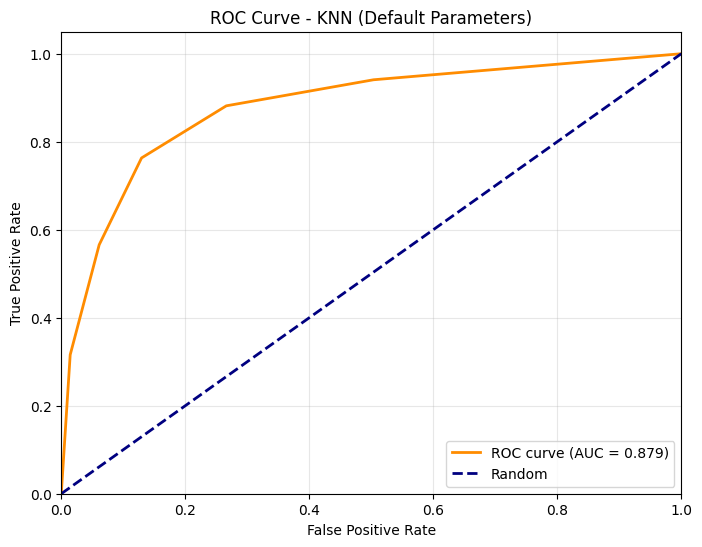

In [113]:
plt.figure(figsize=(8, 6))
fpr_knn_default, tpr_knn_default, _ = roc_curve(y_test, y_prob_test_knn_default)
plt.plot(fpr_knn_default, tpr_knn_default, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_knn_default:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (Default Parameters)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

#### Обучение модели с подобранными эффективными гиперпараметрами

In [116]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_selected, y_train)

print(f"Лучшие параметры: {knn_grid.best_params_}")
print(f"Лучший F1-score на CV: {knn_grid.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Лучший F1-score на CV: 0.8496


In [117]:
knn_best = knn_grid.best_estimator_
knn_best.fit(X_train_selected, y_train)

# Предсказания
y_pred_train_knn = knn_best.predict(X_train_selected)
y_prob_train_knn = knn_best.predict_proba(X_train_selected)[:, 1]
y_pred_test_knn = knn_best.predict(X_test_selected)
y_prob_test_knn = knn_best.predict_proba(X_test_selected)[:, 1]

# Метрики для обучающего множества
accuracy_train_knn = accuracy_score(y_train, y_pred_train_knn)
precision_macro_train_knn = precision_score(y_train, y_pred_train_knn, average='macro')
precision_micro_train_knn = precision_score(y_train, y_pred_train_knn, average='micro')
recall_macro_train_knn = recall_score(y_train, y_pred_train_knn, average='macro')
recall_micro_train_knn = recall_score(y_train, y_pred_train_knn, average='micro')
f1_macro_train_knn = f1_score(y_train, y_pred_train_knn, average='macro')
f1_micro_train_knn = f1_score(y_train, y_pred_train_knn, average='micro')
roc_auc_train_knn = roc_auc_score(y_train, y_prob_train_knn)

print("Метрики для обучающего множества:")
print(f"Accuracy:           {accuracy_train_knn:.4f}")
print(f"Precision (macro):  {precision_macro_train_knn:.4f}")
print(f"Precision (micro):  {precision_micro_train_knn:.4f}")
print(f"Recall (macro):     {recall_macro_train_knn:.4f}")
print(f"Recall (micro):     {recall_micro_train_knn:.4f}")
print(f"F1-Score (macro):   {f1_macro_train_knn:.4f}")
print(f"F1-Score (micro):   {f1_micro_train_knn:.4f}")
print(f"ROC-AUC:           {roc_auc_train_knn:.4f}")

# Метрики для тестового множества
accuracy_test_knn = accuracy_score(y_test, y_pred_test_knn)
precision_macro_test_knn = precision_score(y_test, y_pred_test_knn, average='macro')
precision_micro_test_knn = precision_score(y_test, y_pred_test_knn, average='micro')
recall_macro_test_knn = recall_score(y_test, y_pred_test_knn, average='macro')
recall_micro_test_knn = recall_score(y_test, y_pred_test_knn, average='micro')
f1_macro_test_knn = f1_score(y_test, y_pred_test_knn, average='macro')
f1_micro_test_knn = f1_score(y_test, y_pred_test_knn, average='micro')
roc_auc_test_knn = roc_auc_score(y_test, y_prob_test_knn)

print("\nМетрики для тестового множества:")
print(f"Accuracy:           {accuracy_test_knn:.4f}")
print(f"Precision (macro):  {precision_macro_test_knn:.4f}")
print(f"Precision (micro):  {precision_micro_test_knn:.4f}")
print(f"Recall (macro):     {recall_macro_test_knn:.4f}")
print(f"Recall (micro):     {recall_micro_test_knn:.4f}")
print(f"F1-Score (macro):   {f1_macro_test_knn:.4f}")
print(f"F1-Score (micro):   {f1_micro_test_knn:.4f}")
print(f"ROC-AUC:           {roc_auc_test_knn:.4f}")

print("=" * 53)
print(classification_report(y_test, y_pred_test_knn))

Метрики для обучающего множества:
Accuracy:           1.0000
Precision (macro):  1.0000
Precision (micro):  1.0000
Recall (macro):     1.0000
Recall (micro):     1.0000
F1-Score (macro):   1.0000
F1-Score (micro):   1.0000
ROC-AUC:           1.0000

Метрики для тестового множества:
Accuracy:           0.8698
Precision (macro):  0.8607
Precision (micro):  0.8698
Recall (macro):     0.8516
Recall (micro):     0.8698
F1-Score (macro):   0.8558
F1-Score (micro):   0.8698
ROC-AUC:           0.9131
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       278
           1       0.83      0.79      0.81       152

    accuracy                           0.87       430
   macro avg       0.86      0.85      0.86       430
weighted avg       0.87      0.87      0.87       430



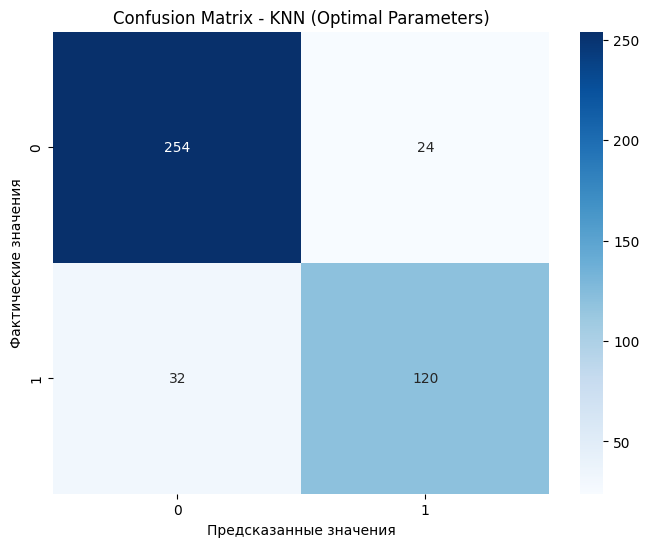

In [119]:
plt.figure(figsize=(8, 6))
cm_knn = confusion_matrix(y_test, y_pred_test_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])
plt.title('Confusion Matrix - KNN (Optimal Parameters)')
plt.ylabel('Фактические значения')
plt.xlabel('Предсказанные значения')
plt.show()

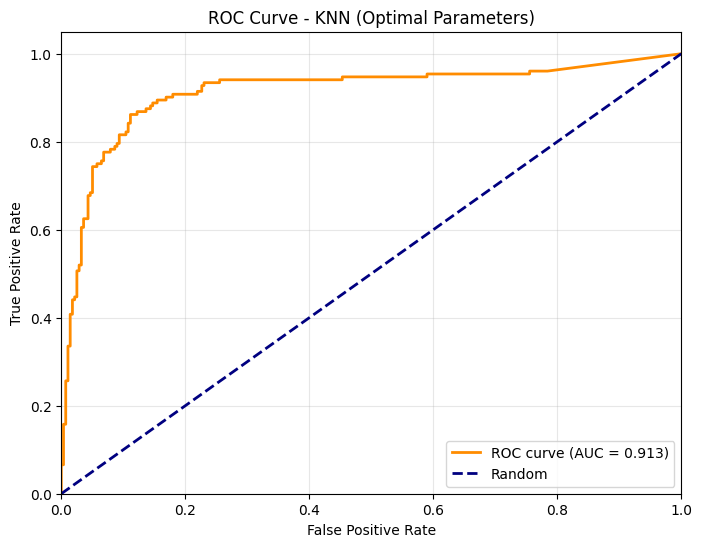

In [120]:
plt.figure(figsize=(8, 6))
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_test_knn)
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_test_knn:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (Optimal Parameters)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [122]:
comparison_data_knn = {
    'Метрика': [
        'Accuracy', 'Precision (macro)', 'Precision (micro)', 
        'Recall (macro)', 'Recall (micro)', 'F1-Score (macro)', 
        'F1-Score (micro)', 'ROC-AUC'
    ],
    'Default_Train': [
        accuracy_train_knn_default, precision_macro_train_knn_default,
        precision_micro_train_knn_default, recall_macro_train_knn_default,
        recall_micro_train_knn_default, f1_macro_train_knn_default,
        f1_micro_train_knn_default, roc_auc_train_knn_default
    ],
    'Best_Train': [
        accuracy_train_knn, precision_macro_train_knn,
        precision_micro_train_knn, recall_macro_train_knn,
        recall_micro_train_knn, f1_macro_train_knn,
        f1_micro_train_knn, roc_auc_train_knn
    ],
    'Default_Test': [
        accuracy_test_knn_default, precision_macro_test_knn_default,
        precision_micro_test_knn_default, recall_macro_test_knn_default,
        recall_micro_test_knn_default, f1_macro_test_knn_default,
        f1_micro_test_knn_default, roc_auc_test_knn_default
    ],
    'Best_Test': [
        accuracy_test_knn, precision_macro_test_knn,
        precision_micro_test_knn, recall_macro_test_knn,
        recall_micro_test_knn, f1_macro_test_knn,
        f1_micro_test_knn, roc_auc_test_knn
    ]
}

comparison_df_knn = pd.DataFrame(comparison_data_knn)
comparison_df_knn['Train_Diff'] = comparison_df_knn['Best_Train'] - comparison_df_knn['Default_Train']
comparison_df_knn['Test_Diff'] = comparison_df_knn['Best_Test'] - comparison_df_knn['Default_Test']

print("Сравнение метрик:")
print(comparison_df_knn.round(4))

Сравнение метрик:
             Метрика  Default_Train  Best_Train  Default_Test  Best_Test  \
0           Accuracy           0.91        1.00          0.83       0.87   
1  Precision (macro)           0.90        1.00          0.82       0.86   
2  Precision (micro)           0.91        1.00          0.83       0.87   
3     Recall (macro)           0.90        1.00          0.82       0.85   
4     Recall (micro)           0.91        1.00          0.83       0.87   
5   F1-Score (macro)           0.90        1.00          0.82       0.86   
6   F1-Score (micro)           0.91        1.00          0.83       0.87   
7            ROC-AUC           0.96        1.00          0.88       0.91   

   Train_Diff  Test_Diff  
0        0.09       0.04  
1        0.10       0.04  
2        0.09       0.04  
3        0.10       0.03  
4        0.09       0.04  
5        0.10       0.04  
6        0.09       0.04  
7        0.04       0.03  


Модель показала хороший результат. Однако после подбора гиперпараметров появилось явное переобучение. В целом качество модели также улучшилось, количество ошибок уменьшилось